<h1 style="text-align:center;">3D models of TCRs recognizing an immunodominant Yellow Fever epitope unravel the structural basis of specificity and cross-reactivity</h1>

In [1]:
import os
import glob
import shutil
import pandas as pd
import numpy as np
import re

from Bio.PDB import PDBList
from pathlib import Path
from Bio.PDB import PDBParser, NeighborSearch, PDBIO, Superimposer, MMCIFParser
from Bio.SeqUtils import seq1

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

import pickle
#import MDAnalysis as mda
#from MDAnalysis.coordinates.PDB import PDBWriter
from scipy.spatial.distance import cdist
from sklearn.metrics import pairwise_distances
from sklearn.cluster import KMeans

std_pal = sns.color_palette("deep")

# Colors

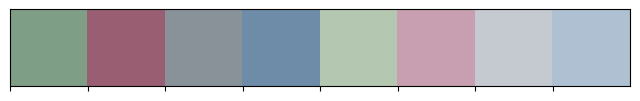

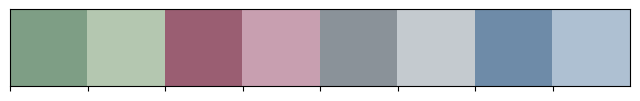

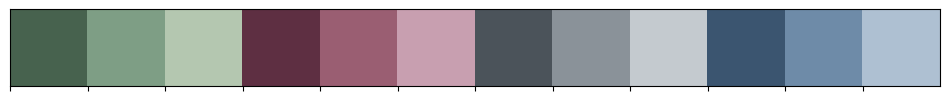

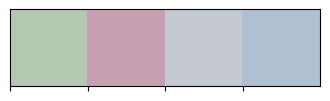

In [3]:
# ---- paper palette (two lightest shades per family) ----------------
# families: green · red · grey · blue ; (mid, light)
paper_pal_families = {
    'green': ['#7E9E85', '#B4C7B0'],
    'red':   ['#9A5E72', '#C89FB0'],
    'grey':  ['#8A9299', '#C4CACF'],
    'blue':  ['#6E8BA8', '#AEC0D2'],
}

# palette 1 — ordered by level: all darker, then all lighter
paper_pal_level = [paper_pal_families[f][lvl]
                   for lvl in range(2)
                   for f in paper_pal_families]
# ['#7E9E85','#9A5E72','#8A9299','#6E8BA8',   # darker of the two
#  '#B4C7B0','#C89FB0','#C4CACF','#AEC0D2']   # lighter

# palette 2 — ordered by color: each family's two shades together
paper_pal_color = [c for f in paper_pal_families for c in paper_pal_families[f]]
# ['#7E9E85','#B4C7B0','#9A5E72','#C89FB0',
#  '#8A9299','#C4CACF','#6E8BA8','#AEC0D2']

sns.palplot(paper_pal_level)
sns.palplot(paper_pal_color)

paper_pal_families3 = {
    'green': ['#47624E', '#7E9E85', '#B4C7B0'],
    'red':   ['#5E2F42', '#9A5E72', '#C89FB0'],
    'grey':  ['#4B535A', '#8A9299', '#C4CACF'],   # cool slate-grey
    'blue':  ['#3B5570', '#6E8BA8', '#AEC0D2'],
}

# by color, dark -> light within each family (12 colors)
paper_pal_color3 = [c for f in paper_pal_families3 for c in paper_pal_families3[f]]
# ['#47624E','#7E9E85','#B4C7B0',   # green
#  '#5E2F42','#9A5E72','#C89FB0',   # red
#  '#4B535A','#8A9299','#C4CACF',   # grey
#  '#3B5570','#6E8BA8','#AEC0D2']   # blue

sns.palplot(paper_pal_color3)

# palette — lightest shade of each family (green · red · grey · blue)
paper_pal_light = [paper_pal_families3[f][-1] for f in paper_pal_families3]
# ['#B4C7B0', '#C89FB0', '#C4CACF', '#AEC0D2']

sns.palplot(paper_pal_light)


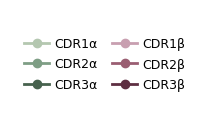

In [145]:
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt

cdr_colors = {
    'CDR1α': '#B4C7B0', 'CDR2α': '#7E9E85', 'CDR3α': '#47624E',
    'CDR1β': '#C89FB0', 'CDR2β': '#9A5E72', 'CDR3β': '#5E2F42',
}
order = ['CDR1α', 'CDR2α', 'CDR3α', 'CDR1β', 'CDR2β', 'CDR3β']
handles = [Line2D([0], [0], color=cdr_colors[k], lw=2, marker='o', markersize=6, label=k)
           for k in order]

fig, ax = plt.subplots(figsize=(2.2, 1.4))
ax.axis('off')
ax.legend(handles=handles, ncol=2, frameon=False, loc='center',
          handletextpad=0.4, columnspacing=1.2, labelspacing=0.6, fontsize=9)
fig.tight_layout()
fig.savefig('Figures/CDR_legend.svg', bbox_inches='tight')

# Identification A0201_LLWNGPMAV:TCR binding modes

## Exclude MAIT cells

In [59]:
topdir = 'data_julien'
batch = 'LAU5013/YF_LAU5013_sc_WT'

csv_file = glob.glob(f'{topdir}/{batch}/YF_LAU5013_sc_WT_AF3_anno.csv')[0]
df = pd.read_csv(csv_file)

mait_mask = (df['TRAV'] == 'TRAV1-2') & (df['TRAJ'].isin(['TRAJ33', 'TRAJ20', 'TRAJ12']))
df.loc[mait_mask, 'TEMPOproblem'] = 'MAIT'

df.to_csv(f'{topdir}/{batch}/YF_LAU5013_sc_WT_AF3_anno.csv', index=False)

## CDR conformational descriptor

Each model is superposed onto the **MHC** (Cα of chain A), placing all TCRs in a
common MHC reference frame so the descriptor captures where each loop sits over
the groove, not just its internal shape.

For every model we locate the six CDR loops by sequence match and extract their
Cα coordinates. Because loops differ in length, each loop's Cα trace is treated
as a 3D curve and **resampled to a fixed number of points evenly spaced along its
arc length** (target = median loop length per CDR across all TCRs). This keeps the
full loop — including the apex — and makes point *k* the same fractional position
along the loop in every TCR, so loops of different length become comparable.

The resampled coordinates of all six CDRs are concatenated into one vector per
TCR (`coord_matrix.pkl`), which is then used for PCA / UMAP of the conformational
landscape.

In [32]:
# AF models for YF-epitope  — arc-length resampled CDR descriptor
from scipy.interpolate import interp1d  # not strictly needed; np.interp used below

def extract_cdr_coords(pdb_path, cdr_dict, chain_map={"TRA":"A","TRB":"B"}):
    """Extract CA coordinates of each CDR by matching its sequence in the chain."""
    parser = PDBParser(QUIET=True)
    structure = parser.get_structure("pdb", pdb_path)
    cdr_coords = {}
    for chain_label, chain_id in chain_map.items():
        chain_obj = structure[0][chain_id]
        residues = [res for res in chain_obj if res.id[0] == " " and "CA" in res]
        seq = "".join([seq1(res.get_resname()) for res in residues])
        cdr_coords[chain_label] = {}
        for i, cdr_key in enumerate([f"CDR1{chain_label[-1]}", f"CDR2{chain_label[-1]}", f"CDR3{chain_label[-1]}"], 1):
            cdr_seq = cdr_dict[cdr_key].upper()
            L = len(cdr_seq)
            start_idx = seq.find(cdr_seq)
            if start_idx == -1:
                print(f"Warning: CDR {cdr_key} sequence not found in chain {chain_id} of {pdb_path}")
                return None
            coords = np.array([res["CA"].get_coord() for res in residues[start_idx:start_idx + L]])
            cdr_coords[chain_label][f"cdr{i}"] = coords
    return cdr_coords


def resample_loop(coords, n_points):
    """Resample a CA trace (n,3) to n_points evenly spaced along its arc length."""
    coords = np.asarray(coords, float)
    if len(coords) == n_points:
        return coords
    if len(coords) == 1:
        return np.repeat(coords, n_points, axis=0)
    d = np.r_[0, np.cumsum(np.linalg.norm(np.diff(coords, axis=0), axis=1))]
    if d[-1] == 0:                                   # degenerate: all points identical
        return np.repeat(coords[:1], n_points, axis=0)
    u = d / d[-1]                                    # cumulative arc length, 0..1
    ut = np.linspace(0, 1, n_points)
    return np.column_stack([np.interp(ut, u, coords[:, k]) for k in range(3)])


def build_coord_matrix(cdr_coord_dict, target_lengths):
    """Flatten resampled CDR1/2/3 (both chains) into one vector per TCR."""
    coord_matrix = []
    for tcr, chains in cdr_coord_dict.items():
        vec = []
        for chain, cdrs in chains.items():
            for cdr_name in ["cdr1", "cdr2", "cdr3"]:
                N = target_lengths[chain][cdr_name]
                vec.extend(resample_loop(cdrs[cdr_name], N).flatten())
        coord_matrix.append(vec)
    return np.array(coord_matrix)


# ---- extract CDR coordinates for every model -------------------------------
cdr_coord_dict = {}

topdir = 'data_julien'
batches = ['LAU5013/YF_LAU5013_sc_WT', 'Public_Data/YF_public_pairedData_20251010']

for batch in batches:
    batch_short = batch.split('/')[0]
    cdr_coord_dict[batch_short] = {}

    # CDRs annotated with tcr_cdr_annotation.R
    csv_file = glob.glob(f'{topdir}/{batch}/*.csv')[0]
    df = pd.read_csv(csv_file)
    df = df[df["TEMPOproblem"].isna()]

    pdbs = glob.glob(f'{topdir}/{batch}/model_pdb_align_exp/*.pdb')
    pdbs.sort()
    pdbs = [p for p in pdbs if os.path.basename(p.split('.')[0]) in df['id'].values]

    for pdb_file in pdbs:
        pdb_id = os.path.basename(pdb_file.split('.')[0])
        row = df[df["id"] == pdb_id]
        cdr_dict = {cdr: str(row[cdr].values[0]).upper() for cdr in
                    ["cdr1_TRA","cdr2_TRA","cdr3_TRA","cdr1_TRB","cdr2_TRB","cdr3_TRB"]}
        cdr_dict = {
            k.replace("cdr", "CDR").replace("_TRA", "A").replace("_TRB", "B"): v
            for k, v in cdr_dict.items()
        }
        cdr_coords = extract_cdr_coords(pdb_file, cdr_dict, chain_map={"TRA":"B","TRB":"C"})
        if cdr_coords is not None:
            cdr_coord_dict[batch_short][pdb_id] = cdr_coords


# ---- target lengths = MEDIAN loop length across all TCRs -------------------
target_cdr_lengths = {}
for chain_label in ["TRA", "TRB"]:
    target_cdr_lengths[chain_label] = {}
    for cdr_name in ["cdr1", "cdr2", "cdr3"]:
        all_lengths = [chains[chain_label][cdr_name].shape[0]
                       for pdbs in cdr_coord_dict.values()
                       for chains in pdbs.values()]
        target_cdr_lengths[chain_label][cdr_name] = int(np.round(np.median(all_lengths)))

print("target (median) CDR lengths:", target_cdr_lengths)


# ---- build coordinate matrix ----------------------------------------------
lst = []
for batch, batch_dict in cdr_coord_dict.items():
    coord_matrix = build_coord_matrix(batch_dict, target_cdr_lengths)
    df = pd.DataFrame(coord_matrix)
    df.insert(0, 'batch', batch)
    df.insert(0, 'PDB', list(batch_dict.keys()))
    lst.append(df)

df = pd.concat(lst)

# ---- annotate germline segments -------------------------------------------
batches_anno = {
    'LAU5013' : 'data_julien/LAU5013/YF_LAU5013_sc_WT/YF_LAU5013_sc_WT_AF3_anno.csv',
    'Public_Data' : 'data_julien/Public_Data/YF_public_pairedData_20251010/YF_public_pairedData_20251010_AF3_anno.csv'
}

lst = []
for batch, csv_file in batches_anno.items():
    df_anno = pd.read_csv(csv_file)
    df_anno = df_anno.rename(columns={'id':'PDB'})
    df_anno = df_anno[['PDB', 'TRAV', 'TRAJ', 'cdr3_TRA', 'TRBV', 'TRBJ', 'cdr3_TRB', 'AF3_iptm_pair_mean']]
    df_anno['batch'] = batch
    lst.append(df_anno)

anno = pd.concat(lst)

df_merged = pd.merge(anno, df, on=['PDB', 'batch'])
df_merged.to_pickle('coord_matrix.pkl')

# saved for reference (replaces the old min_cdr_lengths.pkl)
with open("target_cdr_lengths.pkl", "wb") as f:
    pickle.dump(target_cdr_lengths, f)

target (median) CDR lengths: {'TRA': {'cdr1': 6, 'cdr2': 6, 'cdr3': 10}, 'TRB': {'cdr1': 5, 'cdr2': 6, 'cdr3': 14}}


## Perform PCA

         PDB        batch      TRAV        PC1        PC2       tmp
0    tcr0001      LAU5013  TRAV12-2   0.625957   4.714019  TRAV12-2
1    tcr0005      LAU5013  TRAV12-2   0.779552  -3.061647  TRAV12-2
2    tcr0010      LAU5013  TRAV12-1  -5.670480   6.548908  TRAV12-1
3    tcr0014      LAU5013  TRAV12-2  -2.875493   1.071525  TRAV12-2
4    tcr0018      LAU5013  TRAV12-2   4.312536  -3.695602  TRAV12-2
..       ...          ...       ...        ...        ...       ...
511  tcr0384  Public_Data    TRAV17  -8.906055  -9.528403     other
512  tcr0385  Public_Data  TRAV12-2   0.297821  12.410889  TRAV12-2
513  tcr0386  Public_Data    TRAV27  -7.847559   1.722416    TRAV27
514  tcr0387  Public_Data  TRAV12-2  12.104648  -2.883792  TRAV12-2
515  tcr0388  Public_Data  TRAV12-2   0.918755   1.412342  TRAV12-2

[516 rows x 6 columns]
         PDB        batch      TRAV        PC1        PC2       tmp
123  tcr1145      LAU5013     TRAV4 -53.239059 -29.257580     other
377  tcr0176  Public_Dat

/var/folders/mg/jhh2rvf11vd1jd013_6qqg200000gn/T/ipykernel_16467/1624705821.py:19: UserWarning: The palette list has more values (8) than needed (2), which may not be intended.
  sns.scatterplot(df_pca, x='PC1', y='PC2', hue='batch', ax=ax, edgecolor='black', s=15, palette=paper_pal_level)
/var/folders/mg/jhh2rvf11vd1jd013_6qqg200000gn/T/ipykernel_16467/1624705821.py:36: UserWarning: The palette list has more values (8) than needed (4), which may not be intended.
  sns.scatterplot(df_pca, x='PC1', y='PC2', hue='tmp', ax=ax, edgecolor='black', s=15, palette=paper_pal_level)


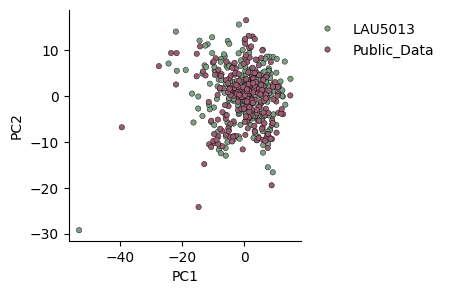

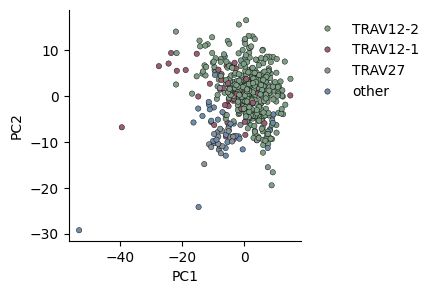

In [61]:
# load coordinate matrix
df = pd.read_pickle('coord_matrix.pkl')
df = df[df['AF3_iptm_pair_mean'] > 0.8]

coord_matrix = df.iloc[:,9:].to_numpy()

pca = PCA(n_components=2)
pcs = pca.fit_transform(coord_matrix)

df_pca = pd.DataFrame()
df_pca['PC1'] = pcs[:,0]
df_pca['PC2'] = pcs[:,1]
df_pca['PDB'] = df['PDB'].values
df_pca["PDB"] = df_pca["PDB"].apply(lambda x: os.path.basename(x).split('.')[0])
df_pca['batch'] = df['batch'].values

fig, ax = plt.subplots(1, 1, figsize=(3,3))

sns.scatterplot(df_pca, x='PC1', y='PC2', hue='batch', ax=ax, edgecolor='black', s=15, palette=paper_pal_level)
ax.legend(bbox_to_anchor=(1,1), frameon=False, loc='upper left')
sns.despine()

# annotate by TRAV
df_pca = df[['PDB', 'batch', 'TRAV']].copy().reset_index(drop=True)
df_pca['PC1'] = pcs[:, 0]
df_pca['PC2'] = pcs[:, 1]
df_pca['PDB'] = df_pca['PDB'].apply(lambda x: os.path.basename(x).split('.')[0])

lst = ['TRAV12-2', 'TRAV12-1', 'TRAV27']
df_pca['tmp'] = np.where(df_pca['TRAV'].isin(lst), df_pca['TRAV'], 'other')
order = ['TRAV12-2', 'TRAV12-1', 'TRAV27', 'other']
df_pca['tmp'] = pd.Categorical(df_pca['tmp'], categories=order, ordered=True)

fig, ax = plt.subplots(1, 1, figsize=(3,3))

sns.scatterplot(df_pca, x='PC1', y='PC2', hue='tmp', ax=ax, edgecolor='black', s=15, palette=paper_pal_level)
ax.legend(bbox_to_anchor=(1,1), frameon=False, loc='upper left')
sns.despine()

print(df_pca)
print(df_pca[df_pca['PC1'] < -30])

## Project YF-data into experimental space

extracted 132 / 134 class-I structures (2 skipped: ['3VXU', '3W0W'])
explained variance: [0.402 0.239]


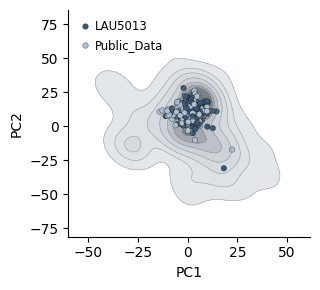

In [34]:
# ===== Experimental class-I structures: same 6-loop descriptor as the YF data =====
target_cdr_lengths = {'TRA': {'cdr1': 6, 'cdr2': 6, 'cdr3': 10},
                      'TRB': {'cdr1': 5, 'cdr2': 6, 'cdr3': 14}}

exp_dir  = 'exp_structures/pdbs_mhc_align'
anno_exp = pd.read_csv('exp_structures/260305_data_structures_motif.csv')
anno_exp = anno_exp[anno_exp['MHC'] == 'classI'].copy()      # MHC-I only

arm_cols = {'TRA': ['cdr1_TRA', 'cdr2_TRA', 'cdr3_TRA'],
            'TRB': ['cdr1_TRB', 'cdr2_TRB', 'cdr3_TRB']}

def extract_cdr_coords_auto(pdb_path, arm_cdrs):
    """Extract CA coords of the 6 CDRs; auto-detect the alpha/beta chain as the
       one whose sequence contains that arm's three CDRs (chain IDs vary here)."""
    st = PDBParser(QUIET=True).get_structure('x', pdb_path)
    chains = {}
    for ch in st[0]:
        res = [r for r in ch if r.id[0] == ' ' and 'CA' in r]
        if res:
            chains[ch.id] = (res, ''.join(seq1(r.get_resname()) for r in res))
    out = {}
    for arm, cdrs in arm_cdrs.items():
        hit = next(((res, seq) for res, seq in chains.values()
                    if all(c in seq for c in cdrs)), None)
        if hit is None:
            return None
        res, seq = hit
        out[arm] = {}
        for i, cd in enumerate(cdrs, 1):
            idx = seq.find(cd)
            out[arm][f'cdr{i}'] = np.array([r['CA'].get_coord()
                                            for r in res[idx:idx + len(cd)]])
    return out

cdr_coord_dict_exp, skipped = {}, []
for _, row in anno_exp.iterrows():
    pid = str(row['PDB']).upper()
    pdb_file = os.path.join(exp_dir, f'{pid}.pdb')
    if not os.path.exists(pdb_file):
        skipped.append((pid, 'no pdb')); continue
    arm_cdrs = {arm: [str(row[c]).upper() for c in cols] for arm, cols in arm_cols.items()}
    if any(x == 'NAN' for cds in arm_cdrs.values() for x in cds):
        skipped.append((pid, 'missing CDR')); continue
    coords = extract_cdr_coords_auto(pdb_file, arm_cdrs)
    if coords is None:
        skipped.append((pid, 'chain/sequence not found')); continue
    cdr_coord_dict_exp[pid] = coords

print(f'extracted {len(cdr_coord_dict_exp)} / {len(anno_exp)} class-I structures '
      f'({len(skipped)} skipped: {[p for p, _ in skipped]})')

# same helper + same target lengths -> identical 141-feature layout as the YF matrix
coord_matrix_exp = build_coord_matrix(cdr_coord_dict_exp, target_cdr_lengths)
df_exp = pd.DataFrame(coord_matrix_exp)
df_exp.insert(0, 'PDB', list(cdr_coord_dict_exp.keys()))

meta = anno_exp.copy(); meta['PDB'] = meta['PDB'].str.upper()
df_exp = df_exp.merge(meta[['PDB', 'Epitope', 'MHC Name', 'TRAV', 'TRAJ', 'TRBV', 'TRBJ']],
                      on='PDB', how='left')
df_exp.to_pickle('coord_matrix_exp.pkl')

# ===== PCA on the experimental descriptor =====
meta_cols = ['PDB', 'Epitope', 'MHC Name', 'TRAV', 'TRAJ', 'TRBV', 'TRBJ']
Xexp = df_exp.drop(columns=meta_cols).to_numpy()

pca_exp = PCA(n_components=2, random_state=0)
pcs = pca_exp.fit_transform(Xexp)
df_exp['PC1'], df_exp['PC2'] = pcs[:, 0], pcs[:, 1]
print('explained variance:', np.round(pca_exp.explained_variance_ratio_, 3))   # ~[0.40, 0.24]


# exclude the reverse polarity TCR (PDB id. 9C3E)
df_exp = df_exp[df_exp['PDB'] != '9C3E']

from matplotlib.colors import LinearSegmentedColormap

# original grey wash (white -> light grey -> slate)
kde_cmap = LinearSegmentedColormap.from_list('paper_grey',
                                             ['#E4E8EB', '#C4CACF', '#4B535A'])

fig, ax = plt.subplots(figsize=(3.3, 3))

# filled density
sns.kdeplot(df_exp, x='PC1', y='PC2', ax=ax,
            fill=True, thresh=0.05, levels=8, cmap=kde_cmap, alpha=0.9)
# contour lines on top -> crisp, visible edges
sns.kdeplot(df_exp, x='PC1', y='PC2', ax=ax,
            fill=False, thresh=0.05, levels=8,
            color='#8A9299', linewidths=0.4, alpha=0.8)

# ---- project YF models into the experimental PCA space ----
df_yf = pd.read_pickle('coord_matrix.pkl')
df_yf = df_yf[df_yf['AF3_iptm_pair_mean'] > 0.8].copy()
df_yf[['PC1', 'PC2']] = pca_exp.transform(df_yf.iloc[:, 9:].to_numpy())
df_yf = df_yf.sample(frac=1, random_state=0)

batch_pal = {'LAU5013': '#3B5570', 'Public_Data': '#AEC0D2'}   # dark blue / light blue
ax.scatter(df_yf['PC1'], df_yf['PC2'],
           c=df_yf['batch'].map(batch_pal),
           edgecolor='black', linewidth=0.2, s=16)

from matplotlib.lines import Line2D
handles = [Line2D([0], [0], marker='o', linestyle='', markerfacecolor=c,
                  markeredgecolor='black', markeredgewidth=0.2, markersize=4, label=b)
           for b, c in batch_pal.items()]
ax.legend(handles=handles, frameon=False, loc='upper left',
          fontsize='small', handlelength=1, handletextpad=0.4)

sns.despine()
fig.tight_layout()
fig.savefig('Figures/Figure_1/exp_kde_YF_projected.svg', bbox_inches='tight')

## Hirarchical clustering in PCA space

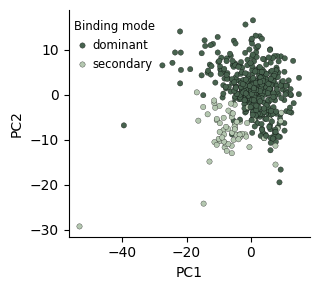

In [14]:
from sklearn.cluster import AgglomerativeClustering

# --- load & filter (same as your PCA cell) ---
df = pd.read_pickle('coord_matrix.pkl')
df = df[df['AF3_iptm_pair_mean'] > 0.8].copy()
coord_matrix = df.iloc[:, 9:].to_numpy()

# --- PCA: 6 components for clustering, first 2 for display ---
pca = PCA(n_components=6, random_state=0)
pcs = pca.fit_transform(coord_matrix)

# --- Ward clustering on the 6 PCs ---
labels = AgglomerativeClustering(n_clusters=2, linkage='ward').fit_predict(pcs)

# --- name clusters by size: largest -> 0 (dominant), other -> 1 (secondary) ---
major_id     = pd.Series(labels).value_counts().idxmax()
cluster_id   = np.where(labels == major_id, 0, 1)                      # for the CSV
cluster_name = np.where(labels == major_id, 'dominant', 'secondary')  # for the legend

# --- assemble plotting frame ---
df_pca = pd.DataFrame({
    'PC1': pcs[:, 0],
    'PC2': pcs[:, 1],
    'cluster': cluster_name,
    'PDB': [os.path.basename(p).split('.')[0] for p in df['PDB'].values],
    'batch': df['batch'].values,
    'TRAV': df['TRAV'].values,
})

# --- colours: dominant = dark green, secondary = light green ---
mode_pal = {'dominant': '#47624E', 'secondary': '#B4C7B0'}

hue_order = ['dominant', 'secondary']
fig, ax = plt.subplots(1, 1, figsize=(3.3, 3))
sns.scatterplot(df_pca, x='PC1', y='PC2', hue='cluster', hue_order=hue_order, ax=ax,
                edgecolor='black', linewidth=0.2, s=15, palette=mode_pal)
ax.legend(title='Binding mode', bbox_to_anchor=(-0.02, 1), frameon=False,
          loc='upper left', fontsize='small', title_fontsize='small',
          handlelength=1, handletextpad=0.4)
sns.despine()

# save df for TSP generation  (cluster as 0 / 1)
cols = ['PDB', 'TRAV', 'TRAJ', 'cdr3_TRA', 'TRBV', 'TRBJ', 'cdr3_TRB', 'batch']

df_out = df[cols].copy()
df_out['PDB'] = df_out['PDB'].apply(lambda x: os.path.basename(x).split('.')[0])
df_out['cluster'] = cluster_id            # 0 = dominant, 1 = secondary
df_out['model'] = [f"{c.capitalize()} binding mode" for c in cluster_name]
# -> 'Dominant binding mode' / 'Secondary binding mode'
df_out.to_csv('df_pca_clusters.csv', index=False)
df_out

fig.tight_layout()
fig.savefig('Figures/Figure_1/pca_binding_modes.svg', bbox_inches='tight')

## Hyperparameters

In [37]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram

df = pd.read_pickle('coord_matrix.pkl')
df = df[df['AF3_iptm_pair_mean'] > 0.8]
X = df.iloc[:, 9:].to_numpy()

N_PC = 6
pca_full = PCA().fit(X)
cum = np.cumsum(pca_full.explained_variance_ratio_)
Z = PCA(n_components=N_PC, random_state=0).fit_transform(X)   # space used for clustering

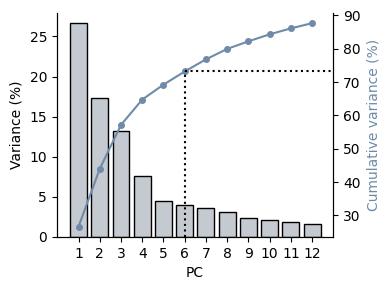

In [42]:
fig, ax = plt.subplots(figsize=(4, 3))
ax.bar(range(1, 13), pca_full.explained_variance_ratio_[:12] * 100,
       color='#C4CACF', edgecolor='k')
ax2 = ax.twinx()
ax2.plot(range(1, 13), cum[:12] * 100, '-o', color='#6E8BA8', ms=4)

ycut = cum[N_PC - 1] * 100
xmax = ax.get_xlim()[1]
ymin = ax2.get_ylim()[0]

# vertical line stops at the cumulative level; horizontal line runs from there to the right axis
ax2.vlines(N_PC, ymin, ycut, ls=':', color='black')
ax2.hlines(ycut, N_PC, xmax, ls=':', color='black')

ax.set_xlim(right=xmax)
ax2.set_ylim(bottom=ymin)   # keep the vertical line flush with the x-axis

ax.set_xlabel('PC')
ax.set_ylabel('Variance (%)')
ax2.set_ylabel('Cumulative variance (%)', color='#6E8BA8')
ax.set_xticks(range(1, 13))
sns.despine(right=False)
fig.tight_layout()
fig.savefig('Figures_SI/pca_hyperparams.svg', bbox_inches='tight')

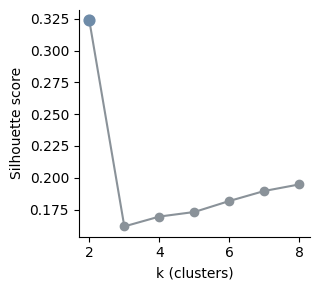

In [43]:
ks = range(2, 9)
sils = [silhouette_score(Z, AgglomerativeClustering(n_clusters=k, linkage='ward').fit_predict(Z))
        for k in ks]

fig, ax = plt.subplots(figsize=(3.3, 3))
ax.plot(list(ks), sils, '-o', color='#8A9299')
ax.scatter([2], [sils[0]], color='#6E8BA8', zorder=5, s=60)   # highlight k=2
ax.set_xlabel('k (clusters)')
ax.set_ylabel('Silhouette score')
sns.despine()
plt.tight_layout()
fig.savefig('Figures_SI/silhouette_score.svg', bbox_inches='tight')

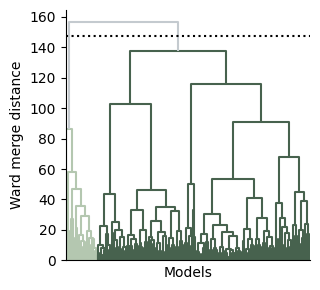

In [40]:
from scipy.cluster.hierarchy import set_link_color_palette

L = linkage(Z, method='ward')
set_link_color_palette([  '#B4C7B0','#47624E',])   # the two clusters (was orange, green)

fig, ax = plt.subplots(figsize=(3.3, 3))
dendrogram(L, ax=ax, no_labels=True,
           color_threshold=L[-1, 2] * 0.99,
           above_threshold_color='#C4CACF')       # links above the cut (was blue)
ax.axhline(L[-2, 2] + (L[-1, 2] - L[-2, 2]) / 2, ls=':', color='black')
ax.set_xlabel('Models')
ax.set_ylabel('Ward merge distance')
sns.despine()
plt.tight_layout()

set_link_color_palette(None)   # reset so other dendrograms aren't affected
plt.tight_layout()
fig.savefig('Figures_SI/ward_distance.svg', bbox_inches='tight')

## Which loops define the binding-mode split?

For each CDR loop we ask how strongly it distinguishes the two conformational
clusters, using a per-loop **F-ratio = between-cluster variance / within-cluster
variance** (the logic of a one-way ANOVA, summed over the loop's Cα coordinates
in the MHC-aligned frame):

- **within-cluster variance** — how tightly the loop's coordinates sit around
  their own cluster mean (spread *inside* a mode);
- **between-cluster variance** — how far the two cluster means are from the
  global mean (difference *between* modes).

A high F means the loop occupies clearly different positions in the two modes
relative to its within-mode spread, i.e. that loop is what the split is built on.
Because F is a *ratio* of two sums over the same coordinates, it is independent of
loop length and directly comparable across CDRs.

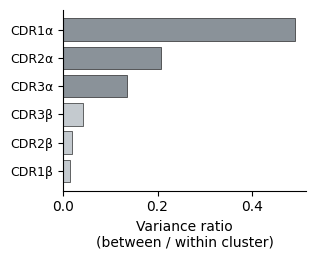

In [96]:
import pickle

lab = cluster_id                     # from the clustering cell
X   = df.iloc[:, 9:].to_numpy()
tl  = pickle.load(open('target_cdr_lengths.pkl', 'rb'))

loops  = [('TRA','cdr1'),('TRA','cdr2'),('TRA','cdr3'),
          ('TRB','cdr1'),('TRB','cdr2'),('TRB','cdr3')]
greek  = {'A': 'α', 'B': 'β'}
labels = [f'CDR{n[-1]}{greek[c[-1]]}' for c, n in loops]   # CDR1α, CDR2α, ..., CDR3β
sizes  = [tl[c][n]*3 for c, n in loops]
starts = np.r_[0, np.cumsum(sizes)][:-1]
cnt    = np.array([(lab == g).sum() for g in np.unique(lab)])

rows = []
for L, s, sz in zip(labels, starts, sizes):
    blk = X[:, s:s+sz]
    win = np.mean([blk[lab == g].var(axis=0).sum() for g in np.unique(lab)])
    gm  = np.array([blk[lab == g].mean(axis=0) for g in np.unique(lab)])
    bet = (cnt[:, None] * (gm - blk.mean(0))**2).sum() / len(blk)
    rows.append((L, bet/(win+1e-12)))

t = pd.DataFrame(rows, columns=['loop', 'F']).sort_values('F')

top3 = set(t.nlargest(3, 'F')['loop'])
colors = ['#8A9299' if L in top3 else '#C4CACF' for L in t['loop']]

fig, ax = plt.subplots(figsize=(3.3, 2.7))
ax.barh(t['loop'], t['F'], color=colors, edgecolor='k', linewidth=0.4)
ax.set_xlabel('Variance ratio\n(between / within cluster)')
sns.despine()
ax.tick_params(axis='x', labelsize=10)
ax.tick_params(axis='y', labelsize=9)   # loop names a bit smaller
fig.tight_layout()
fig.savefig('Figures/variance_ratio.svg', bbox_inches='tight')

## CDR3A-lengths

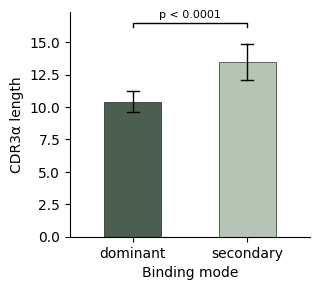

In [30]:
from scipy.stats import mannwhitneyu

dfc = pd.read_csv('df_pca_clusters.csv')
dfc['cdr3a_len'] = dfc['cdr3_TRA'].str.len()

a = dfc.loc[dfc.cluster == 0, 'cdr3a_len']
b = dfc.loc[dfc.cluster == 1, 'cdr3a_len']
U, p = mannwhitneyu(a, b, alternative='two-sided')
p_txt = 'p < 0.0001' if p < 1e-4 else f'p = {p:.3g}'

# colours: dominant (0) = dark green, secondary (1) = light green
mode_pal = {0: '#47624E', 1: '#B4C7B0'}

fig, ax = plt.subplots(figsize=(3.3, 3))
sns.barplot(dfc, x='cluster', y='cdr3a_len', ax=ax,
            hue='cluster', palette=mode_pal, legend=False,
            width=0.5, edgecolor='black', linewidth=0.4,
            errorbar='sd', capsize=0.1,
            err_kws={'color': 'black', 'linewidth': 1})

ax.set_xlim(-0.55, 1.55)          # pulls bars in from the edges / closer together
ax.set_xlabel('Binding mode')
ax.set_ylabel('CDR3α length')
ax.set_xticks([0, 1])
ax.set_xticklabels(['dominant', 'secondary'])

# significance bracket  (closer to the bars)
y = dfc['cdr3a_len'].max() - 1.5
ax.plot([0, 0, 1, 1], [y-0.3, y, y, y-0.3], lw=1, color='black')
ax.text(0.5, y + 0.22, p_txt, ha='center', va='bottom', fontsize=8)

sns.despine()
plt.tight_layout()
fig.savefig('Figures/Figure_1/CDR3A_length.svg', bbox_inches='tight')

# Structure - specificity relationship

In [87]:
import glob, os, numpy as np, pandas as pd
from Bio.PDB import PDBParser
from Bio.SeqUtils import seq1
from scipy.spatial.distance import cdist

CUTOFF = 3.5   # heavy-atom contact distance (Å)
DIRS = {'LAU5013':     'data_julien/LAU5013/YF_LAU5013_sc_WT/model_pdb_align_exp',
        'Public_Data': 'data_julien/Public_Data/YF_public_pairedData_20251010/model_pdb_align_exp'}

# full CDR sequences per model, keyed on (batch, id) — ids repeat across batches!
anno = []
for b, pat in [('LAU5013', 'data_julien/LAU5013/YF_LAU5013_sc_WT/*.csv'),
               ('Public_Data', 'data_julien/Public_Data/YF_public_pairedData_20251010/*.csv')]:
    a = pd.read_csv(glob.glob(pat)[0]); a['batch'] = b; anno.append(a)
anno = pd.concat(anno).set_index(['batch', 'id'])

dfc = pd.read_csv('df_pca_clusters.csv')     # PDB, batch, cluster (0=major, 1=minor)

loops = [('B','cdr1_TRA','CDR1a'), ('B','cdr2_TRA','CDR2a'), ('B','cdr3_TRA','CDR3a'),
         ('C','cdr1_TRB','CDR1b'), ('C','cdr2_TRB','CDR2b'), ('C','cdr3_TRB','CDR3b')]
loop_names = [l[2] for l in loops]
heavy = lambda res: np.array([a.get_coord() for a in res if a.element != 'H'])
resl  = lambda ch: [r for r in ch if r.id[0] == ' ']
p = PDBParser(QUIET=True)

def fingerprint(rows):
    counts = {ln: {} for ln in loop_names}; denom = {ln: 0 for ln in loop_names}; pep_cols = None
    for pid, batch in rows:
        f = os.path.join(DIRS[batch], f'{pid}.pdb')
        if not os.path.exists(f) or (batch, pid) not in anno.index:
            continue
        st = p.get_structure('x', f)[0]; row = anno.loc[(batch, pid)]
        pepres = resl(st['E']); pep_cols = [f'P{i+1}{seq1(r.get_resname())}' for i, r in enumerate(pepres)]
        mhc = resl(st['A'])
        targets  = [(c, heavy(r)) for c, r in zip(pep_cols, pepres)]
        #targets += [('MHC', np.vstack([heavy(r) for r in mhc if 25 <= r.id[1] <= 207]))]
        for cid, col, ln in loops:
            s = str(row[col]).upper(); ch = resl(st[cid])
            seq = ''.join(seq1(r.get_resname()) for r in ch); i = seq.find(s)
            if i < 0:
                continue
            la = np.vstack([heavy(r) for r in ch[i:i+len(s)]]); denom[ln] += 1
            for tn, ta in targets:
                if ta.size and cdist(la, ta).min() <= CUTOFF:
                    counts[ln][tn] = counts[ln].get(tn, 0) + 1
    #cols = pep_cols + ['MHC']
    cols = pep_cols
    return pd.DataFrame({c: [counts[ln].get(c, 0) / denom[ln] if denom[ln] else np.nan
                             for ln in loop_names] for c in cols}, index=loop_names)

for cl, name in [(0, 'major'), (1, 'minor')]:
    rows = [(r.PDB, r.batch) for r in dfc[dfc.cluster == cl].itertuples()]
    fingerprint(rows).to_csv(f'contact_fingerprint_{name}.csv')

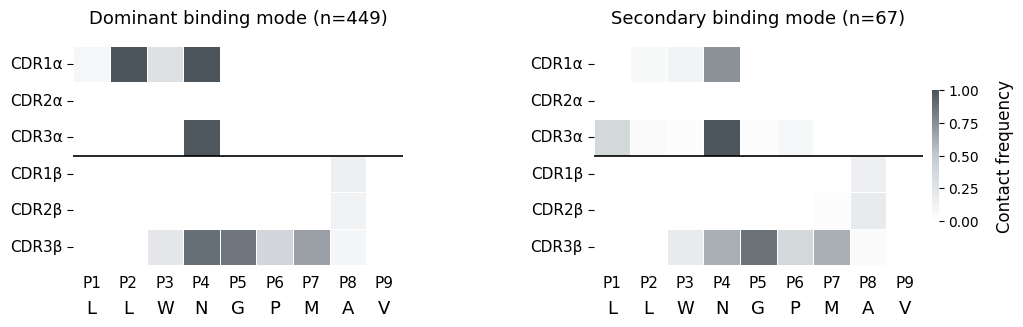

In [11]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

cm = LinearSegmentedColormap.from_list('grey', ['#FFFFFF', '#C4CACF', '#4B535A'])
loop_lab = ['CDR1α', 'CDR2α', 'CDR3α', 'CDR1β', 'CDR2β', 'CDR3β']

# file key -> display label
mode_label = {'major': 'Dominant', 'minor': 'Secondary'}

dfc = pd.read_csv('df_pca_clusters.csv')
ncl = {'major': int((dfc.cluster == 0).sum()), 'minor': int((dfc.cluster == 1).sum())}

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
for ax, name in zip(axes, ['major', 'minor']):
    M = pd.read_csv(f'contact_fingerprint_{name}.csv', index_col=0)
    pep_pos = [c[:-1] for c in M.columns]; pep_aa = [c[-1] for c in M.columns]; nr, ncol = M.shape
    sns.heatmap(M, ax=ax, cmap=cm, vmin=0, vmax=1, linewidths=0.5, linecolor='white',
                cbar=(name == 'minor'),
                cbar_kws={'label': 'Contact frequency', 'shrink': 0.6, 'pad': 0.02})
    ax.set_aspect('equal')                                   # square cells, equal panel width
    ax.set_title(f'{mode_label[name]} binding mode (n={ncl[name]})', fontsize=13, pad=16)
    ax.set_yticks(np.arange(nr)+0.5); ax.set_yticklabels(loop_lab, rotation=0, fontsize=11)
    ax.tick_params(axis='y', length=4, left=True)            # show y tick marks
    ax.set_xticks([])                                        # remove default x-tick labels (keeps manual ones)
    for xi, (pp, aa) in enumerate(zip(pep_pos, pep_aa)):
        ax.text(xi+0.5, nr+0.28, pp, ha='center', va='top', fontsize=11, clip_on=False)
        ax.text(xi+0.5, nr+0.92, aa, ha='center', va='top', fontsize=13, clip_on=False)
    ax.axhline(3, color='k', lw=1.2)                         # alpha | beta separator
    if name == 'minor':
        cbar = ax.collections[0].colorbar
        cbar.set_label('Contact frequency', fontsize=12, labelpad=12)
        cbar.ax.tick_params(labelsize=10)

fig.tight_layout()
fig.savefig('Figures/Figure_1/contact_fingerprint.svg', bbox_inches='tight')

In [72]:
import glob, os, json, numpy as np, pandas as pd
from Bio.PDB import PDBParser
from Bio.SeqUtils import seq1
from scipy.spatial.distance import cdist

# ===== per-position contact fingerprint (major mode) =====
# only V+J+length-matched TCRs so every loop position is comparable across TCRs:
#   alpha: TRAV12-2 + TRAJ30 + CDR3a length 10
#   beta:  TRBV15   + TRBJ2-7 + CDR3b length 13
CUTOFF = 3.5
DIRS = {'LAU5013':     'data_julien/LAU5013/YF_LAU5013_sc_WT/model_pdb_align_exp',
        'Public_Data': 'data_julien/Public_Data/YF_public_pairedData_20251010/model_pdb_align_exp'}

anno = []
for b, pat in [('LAU5013', 'data_julien/LAU5013/YF_LAU5013_sc_WT/*.csv'),
               ('Public_Data', 'data_julien/Public_Data/YF_public_pairedData_20251010/*.csv')]:
    a = pd.read_csv(glob.glob(pat)[0]); a['batch'] = b; anno.append(a)
anno = pd.concat(anno).set_index(['batch', 'id'])

dfc = pd.read_csv('df_pca_clusters.csv'); maj = dfc[dfc.cluster == 0].copy()
maj['la'] = maj['cdr3_TRA'].str.len(); maj['lb'] = maj['cdr3_TRB'].str.len()
alpha = maj[(maj.TRAV == 'TRAV12-2') & (maj.TRAJ == 'TRAJ30')  & (maj.la == 10)]
beta  = maj[(maj.TRBV == 'TRBV15')   & (maj.TRBJ == 'TRBJ2-7') & (maj.lb == 13)]

heavy = lambda res: np.array([a.get_coord() for a in res if a.element != 'H'])
resl  = lambda ch: [r for r in ch if r.id[0] == ' ']
p = PDBParser(QUIET=True); PEP = list('LLWNGPMAV')

def perpos(rows, arm_loops):
    acc, den = {}, {}
    for pid, batch in rows:
        f = os.path.join(DIRS[batch], f'{pid}.pdb')
        if not os.path.exists(f) or (batch, pid) not in anno.index:
            continue
        st = p.get_structure('x', f)[0]; row = anno.loc[(batch, pid)]
        pepres = resl(st['E']); pepat = [heavy(r) for r in pepres]
        pepcols = [f'P{i+1}{c}' for i, c in enumerate(PEP)]
        for cid, col, ln, L in arm_loops:
            s = str(row[col]).upper(); ch = resl(st[cid])
            seq = ''.join(seq1(r.get_resname()) for r in ch); i = seq.find(s)
            if i < 0 or len(s) != L:
                continue
            for pos in range(L):
                k = f'{ln}{pos+1}'; den[k] = den.get(k, 0) + 1; ra = heavy(ch[i+pos])
                for pc, pa in zip(pepcols, pepat):
                    if pa.size and cdist(ra, pa).min() <= CUTOFF:
                        acc[(k, pc)] = acc.get((k, pc), 0) + 1
    labs = [f'{ln}{k+1}' for _, _, ln, L in arm_loops for k in range(L)]
    cols = [f'P{i+1}{c}' for i, c in enumerate(PEP)]
    return pd.DataFrame({c: [acc.get((r, c), 0)/den[r] if den.get(r) else np.nan
                             for r in labs] for c in cols}, index=labs)

Ma = perpos([(r.PDB, r.batch) for r in alpha.itertuples()],
            [('B', 'cdr1_TRA', 'CDR1α', 6), ('B', 'cdr2_TRA', 'CDR2α', 6), ('B', 'cdr3_TRA', 'CDR3α', 10)])
Mb = perpos([(r.PDB, r.batch) for r in beta.itertuples()],
            [('C', 'cdr1_TRB', 'CDR1β', 5), ('C', 'cdr2_TRB', 'CDR2β', 6), ('C', 'cdr3_TRB', 'CDR3β', 13)])
pd.concat([Ma, Mb]).to_csv('contact_fingerprint_major_perpos.csv')
json.dump({'alpha': int(len(alpha)), 'beta': int(len(beta))}, open('contact_fingerprint_major_n.json', 'w'))
print('alpha n=%d  beta n=%d' % (len(alpha), len(beta)))


alpha n=112  beta n=48


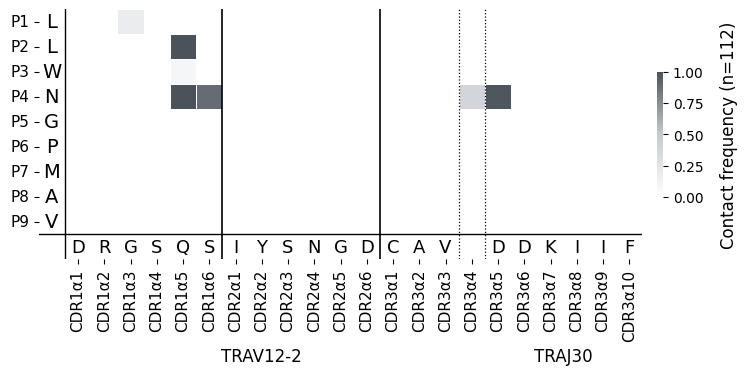

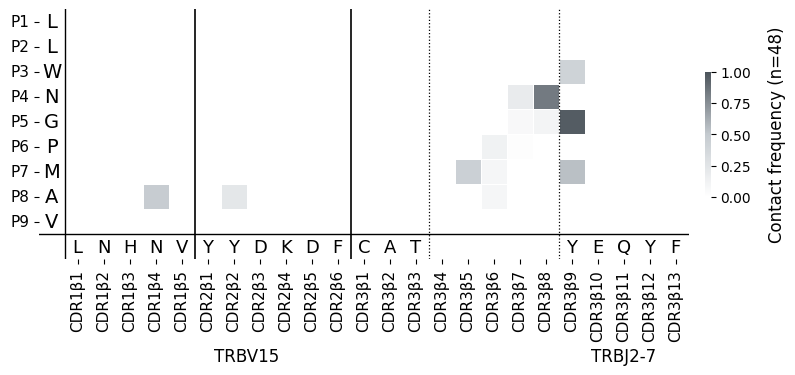

In [3]:
import re, json
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.transforms import blended_transform_factory

M = pd.read_csv('contact_fingerprint_major_perpos.csv', index_col=0)
N = json.load(open('contact_fingerprint_major_n.json'))
cm = LinearSegmentedColormap.from_list('grey', ['#FFFFFF', '#C4CACF', '#4B535A'])
pep_pos = [c[:-1] for c in M.columns]; pep_aa = [c[-1] for c in M.columns]

cfg = {
    'alpha': {'vgene': 'TRAV12-2', 'jgene': 'TRAJ30', 'n': N['alpha'],
              'loops': [('CDR1α', 'DRGSQS'), ('CDR2α', 'IYSNGD'), ('CDR3α', 'CAV DDKIIF')]},
    'beta':  {'vgene': 'TRBV15', 'jgene': 'TRBJ2-7', 'n': N['beta'],
              'loops': [('CDR1β', 'LNHNV'), ('CDR2β', 'YYDKDF'), ('CDR3β', 'CAT     YEQYF')]},
}

def plot_chain(chain, outpng):
    c = cfg[chain]; loops = c['loops']
    res = ''.join(g for _, g in loops)
    cdr_rows = [f'{ln}{k+1}' for ln, g in loops for k in range(len(g))]
    C = M.loc[cdr_rows]; V = C.T.values; npep, ncdr = V.shape
    disp = np.full((npep+1, ncdr+1), np.nan); disp[:npep, 1:] = V
    fig, ax = plt.subplots(figsize=(0.28*ncdr+1.7, 0.32*npep+1.2))
    sns.heatmap(disp, mask=np.isnan(disp), cmap=cm, vmin=0, vmax=1, linewidths=0.5, linecolor='white',
                ax=ax, cbar_kws={'label': f'Contact frequency (n={c["n"]})', 'shrink': 0.5, 'pad': 0.02})
    ax.set_facecolor('white')
    # colorbar: bigger label, closer to plot
    cbar = ax.collections[0].colorbar
    cbar.set_label(f'Contact frequency (n={c["n"]})', fontsize=12, labelpad=12)
    cbar.ax.tick_params(labelsize=10)
    for j, ch in enumerate(res):                              # bottom row: germline residues
        if ch != ' ': ax.text(j+1.5, npep+0.5, ch, ha='center', va='center', fontsize=13)
    for i, aa in enumerate(pep_aa):                          # left col: peptide AA
        ax.text(0.5, i+0.5, aa, ha='center', va='center', fontsize=14)
    ax.set_xticks(np.arange(1, ncdr+1)+0.5); ax.set_xticklabels(cdr_rows, rotation=90, fontsize=11)  # CDR labels bigger
    ax.set_yticks(np.arange(0, npep)+0.5);   ax.set_yticklabels(pep_pos, rotation=0, fontsize=11)
    lens = [len(g) for _, g in loops]; cum = np.cumsum(lens)
    for b in cum[:-1]:
        ax.axvline(1+b, color='k', lw=1.2)
    c3_start = cum[-2]; c3 = loops[-1][1]
    nV = len(re.match(r'\S+', c3).group()); nJ = len(re.search(r'\S+$', c3).group()); L3 = len(c3)
    ax.axvline(1+c3_start+nV, color='k', lw=0.9, ls=':')
    ax.axvline(1+c3_start+(L3-nJ), color='k', lw=0.9, ls=':')
    ax.axhline(npep, color='k', lw=1); ax.axvline(1, color='k', lw=1)
    trans = blended_transform_factory(ax.transData, ax.transAxes)
    v_center = (1 + (1+c3_start+nV)) / 2
    j_center = ((1+c3_start+L3-nJ) + (1+ncdr)) / 2
    ax.text(v_center, -0.35, c['vgene'], transform=trans, ha='center', va='top', fontsize=12, clip_on=False)
    ax.text(j_center, -0.35, c['jgene'], transform=trans, ha='center', va='top', fontsize=12, clip_on=False)
    fig.tight_layout(); fig.savefig(outpng, bbox_inches='tight')

plot_chain('alpha', 'Figures/fp_major_combined_alpha.svg')
plot_chain('beta',  'Figures/fp_major_combined_beta.svg')

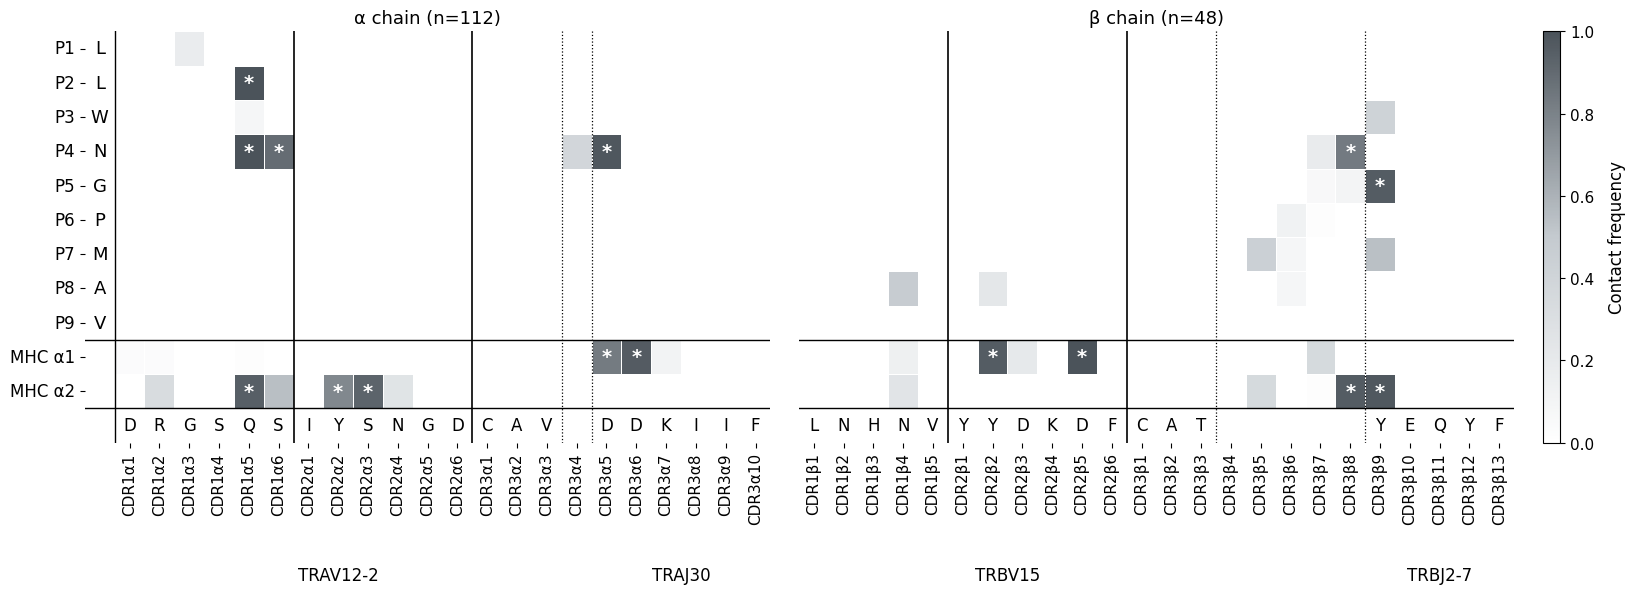

In [7]:
import re, json
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.transforms import blended_transform_factory
from matplotlib.gridspec import GridSpec

M = pd.read_csv('contact_fingerprint_major_perpos_mhc.csv', index_col=0)
N = json.load(open('contact_fingerprint_major_n.json'))
cm = LinearSegmentedColormap.from_list('grey', ['#FFFFFF', '#C4CACF', '#4B535A'])

pep_cols = [c for c in M.columns if c[0] == 'P' and c[1].isdigit()]
mhc_cols = ['MHCα1', 'MHCα2']
row_order = pep_cols + mhc_cols
row_lab = [c[:-1] for c in pep_cols] + ['MHC α1', 'MHC α2']
row_aa  = [c[-1] for c in pep_cols] + ['', '']
npep = len(pep_cols); nrow = len(row_order)

cfg = {'alpha': {'v':'TRAV12-2','j':'TRAJ30','n':N['alpha'],
                 'loops':[('CDR1α','DRGSQS'),('CDR2α','IYSNGD'),('CDR3α','CAV DDKIIF')]},
       'beta':  {'v':'TRBV15','j':'TRBJ2-7','n':N['beta'],
                 'loops':[('CDR1β','LNHNV'),('CDR2β','YYDKDF'),('CDR3β','CAT     YEQYF')]}}
ncols = lambda ch: sum(len(g) for _, g in cfg[ch]['loops'])
na, nb = ncols('alpha'), ncols('beta')

fig = plt.figure(figsize=(0.34*(na+nb)+3.4, 0.34*nrow+1.6))     # wider
gs = GridSpec(1, 3, width_ratios=[na+1, nb, 0.6], wspace=0.06)
axa, axb, axc = fig.add_subplot(gs[0]), fig.add_subplot(gs[1]), fig.add_subplot(gs[2])

def panel(ax, chain, xoff, ylabels):
    c = cfg[chain]; loops = c['loops']; res = ''.join(g for _, g in loops)
    cdr_rows = [f'{ln}{k+1}' for ln, g in loops for k in range(len(g))]
    V = M.loc[cdr_rows, row_order].T.values; ncdr = V.shape[1]
    disp = np.full((nrow+1, ncdr+xoff), np.nan); disp[:nrow, xoff:] = V
    sns.heatmap(disp, mask=np.isnan(disp), cmap=cm, vmin=0, vmax=1,
                linewidths=0.5, linecolor='white', ax=ax, cbar=False)
    ax.set_facecolor('white')
    for r in range(nrow):
        for cc in range(ncdr):
            if np.isfinite(V[r, cc]) and V[r, cc] > 0.75:
                ax.text(xoff+cc+0.5, r+0.5, '*', ha='center', va='center',
                        color='white', fontsize=14, fontweight='bold')
    for j, ch in enumerate(res):
        if ch != ' ': ax.text(j+xoff+0.5, nrow+0.5, ch, ha='center', va='center', fontsize=12)
    if xoff == 1:
        for i, aa in enumerate(row_aa): ax.text(0.5, i+0.5, aa, ha='center', va='center', fontsize=13)
    ax.set_xticks(np.arange(xoff, ncdr+xoff)+0.5); ax.set_xticklabels(cdr_rows, rotation=90, fontsize=11)  # bigger
    if ylabels:
        ax.set_yticks(np.arange(0, nrow)+0.5); ax.set_yticklabels(row_lab, rotation=0, fontsize=12)         # bigger
    else:
        ax.set_yticks([])
    lens = [len(g) for _, g in loops]; cum = np.cumsum(lens)
    for b in cum[:-1]: ax.axvline(xoff+b, color='k', lw=1.2)
    c3s = cum[-2]; c3 = loops[-1][1]
    nV = len(re.match(r'\S+', c3).group()); nJ = len(re.search(r'\S+$', c3).group()); L3 = len(c3)
    ax.axvline(xoff+c3s+nV, color='k', lw=0.9, ls=':'); ax.axvline(xoff+c3s+(L3-nJ), color='k', lw=0.9, ls=':')
    ax.axhline(nrow, color='k', lw=1); ax.axhline(npep, color='k', lw=1)
    if xoff == 1: ax.axvline(1, color='k', lw=1)
    tr = blended_transform_factory(ax.transData, ax.transAxes)
    ax.text((xoff + (xoff+c3s+nV))/2, -0.30, c['v'], transform=tr, ha='center', va='top', fontsize=12, clip_on=False)
    ax.text(((xoff+c3s+L3-nJ) + (xoff+ncdr))/2, -0.30, c['j'], transform=tr, ha='center', va='top', fontsize=12, clip_on=False)
    ax.set_title(f"{'α' if chain=='alpha' else 'β'} chain (n={c['n']})", fontsize=13, pad=6)
    return ax.collections[0]

qm = panel(axa, 'alpha', 1, True)
panel(axb, 'beta', 0, False)
cb = fig.colorbar(qm, cax=axc); cb.set_label('Contact frequency', fontsize=12, labelpad=10); cb.ax.tick_params(labelsize=11)
fig.savefig('Figures/Figure_2/fp_major_combined_mhc.svg', bbox_inches='tight')

# Experimental Validation

## Ala-Scan

In [ ]:
import glob, os, json, numpy as np, pandas as pd
from Bio.PDB import PDBParser
from Bio.SeqUtils import seq1
from scipy.spatial.distance import cdist

# ===== per-position EPITOPE (peptide + MHC) contact frequency, dominant mode =====
# fraction of models where each CDR position contacts peptide (chain E) OR MHC (chain A) <= CUTOFF
#   alpha subset: TRAV12-2 + TRAJ30 + CDR3a length 10
#   beta  subset: any TRBV  + TRBJ2-7 + CDR3b length 13
CUTOFF = 3.5
DIRS = {'LAU5013':     'data_julien/LAU5013/YF_LAU5013_sc_WT/model_pdb_align_exp',
        'Public_Data': 'data_julien/Public_Data/YF_public_pairedData_20251010/model_pdb_align_exp'}

anno = []
for b, pat in [('LAU5013', 'data_julien/LAU5013/YF_LAU5013_sc_WT/*.csv'),
               ('Public_Data', 'data_julien/Public_Data/YF_public_pairedData_20251010/*.csv')]:
    a = pd.read_csv(glob.glob(pat)[0]); a['batch'] = b; anno.append(a)
anno = pd.concat(anno).set_index(['batch', 'id'])

dfc = pd.read_csv('df_pca_clusters.csv'); maj = dfc[dfc.cluster == 0].copy()
maj['la'] = maj['cdr3_TRA'].str.len(); maj['lb'] = maj['cdr3_TRB'].str.len()
alpha = maj[(maj.TRAV == 'TRAV12-2') & (maj.TRAJ == 'TRAJ30') & (maj.la == 10)]      # alpha subset
beta  = maj[(maj.TRBJ == 'TRBJ2-7') & (maj.lb == 13)]                                # beta: ANY TRBV

heavy1 = lambda r: np.array([a.get_coord() for a in r if a.element != 'H'])          # one residue -> atoms
heavyL = lambda residues: (np.vstack([heavy1(r) for r in residues])
                           if residues else np.empty((0, 3)))                        # list of residues -> atoms
resl   = lambda ch: [r for r in ch if r.id[0] == ' ']
p = PDBParser(QUIET=True)

def perpos_epitope(rows, arm_loops):
    """fraction of models where each CDR position contacts peptide OR MHC (<=CUTOFF)."""
    acc, den = {}, {}
    for pid, batch in rows:
        f = os.path.join(DIRS[batch], f'{pid}.pdb')
        if not os.path.exists(f) or (batch, pid) not in anno.index:
            continue
        st = p.get_structure('x', f)[0]; row = anno.loc[(batch, pid)]
        epi = np.vstack([heavyL(resl(st['E'])), heavyL(resl(st['A']))])  # epitope = peptide + MHC
        for cid, col, ln, L in arm_loops:
            s = str(row[col]).upper(); ch = resl(st[cid])
            seq = ''.join(seq1(r.get_resname()) for r in ch); i = seq.find(s)
            if i < 0 or len(s) != L:
                continue
            for pos in range(L):
                k = f'{ln}{pos+1}'; den[k] = den.get(k, 0) + 1
                ra = heavy1(ch[i + pos])
                if ra.size and epi.size and cdist(ra, epi).min() <= CUTOFF:
                    acc[k] = acc.get(k, 0) + 1
    labs = [f'{ln}{k+1}' for _, _, ln, L in arm_loops for k in range(L)]
    return pd.Series({r: (acc.get(r, 0) / den[r] if den.get(r) else np.nan) for r in labs})

Ea = perpos_epitope([(r.PDB, r.batch) for r in alpha.itertuples()],
                    [('B', 'cdr1_TRA', 'CDR1α', 6), ('B', 'cdr2_TRA', 'CDR2α', 6),
                     ('B', 'cdr3_TRA', 'CDR3α', 10)])
Eb = perpos_epitope([(r.PDB, r.batch) for r in beta.itertuples()],
                    [('C', 'cdr1_TRB', 'CDR1β', 5), ('C', 'cdr2_TRB', 'CDR2β', 6),
                     ('C', 'cdr3_TRB', 'CDR3β', 13)])
epi = pd.concat([Ea, Eb]); epi.name = 'epitope_cf'
epi.to_csv('contact_fingerprint_major_epitope_perpos.csv', header=True)
json.dump({'alpha': int(len(alpha)), 'beta': int(len(beta))},
          open('contact_fingerprint_major_epitope_n.json', 'w'))
print('alpha n=%d  beta n=%d' % (len(alpha), len(beta)))

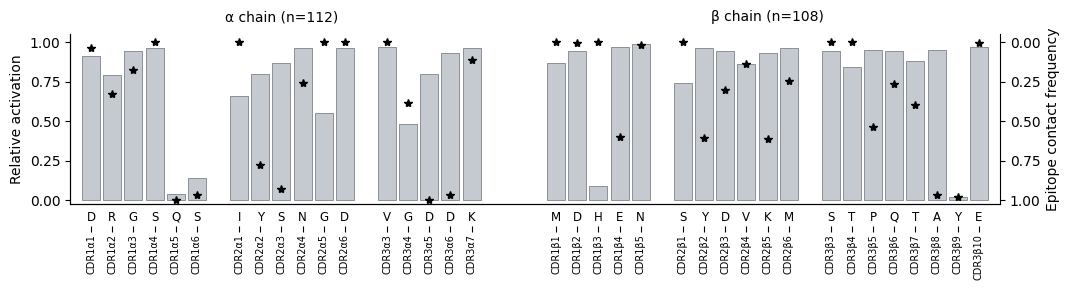

In [63]:
import re, os, json
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

# ========================= inputs =========================
ALA    = 'Figures/Figure_3/YF-AlaScan.xlsx'
EPI    = 'contact_fingerprint_major_epitope_perpos.csv'   # epitope (peptide+MHC) contact freq per CDR position

ala = pd.read_excel(ALA, sheet_name='mutants_CDR_AlaScan')
pat = re.compile(r'(CDR\d[AB])_([A-Z])(\d+)([A-Z])')
m = ala['Name'].apply(lambda n: pat.match(str(n)))
ala = ala[m.notna()].copy()
ala[['loop', 'wt', 'posn', 'mut']] = [x.groups() for x in m.dropna()]
ala['posn'] = ala['posn'].astype(int)
is_excl = ala['Comment'].astype(str).str.strip().str.lower().eq('exclude')
ala = ala[(ala['mut'] == 'A') & (~is_excl)].copy()
ala['activation'] = ala['Results'] / 100.0

loop_lab = {'CDR1A': 'CDR1α', 'CDR2A': 'CDR2α', 'CDR3A': 'CDR3α',
            'CDR1B': 'CDR1β', 'CDR2B': 'CDR2β', 'CDR3B': 'CDR3β'}
ala['llab'] = ala['loop'].map(loop_lab)
ala['label'] = ala['llab'] + ala['posn'].astype(str)
cf = pd.read_csv(EPI, index_col=0)['epitope_cf'].to_dict()      # epitope contact frequency
nmod = json.load(open('contact_fingerprint_major_epitope_n.json'))  # model counts per chain

# ========================= x layout (tested positions only) =========================
loop_order = ['CDR1α', 'CDR2α', 'CDR3α', 'CDR1β', 'CDR2β', 'CDR3β']
GAP, CHAIN_GAP = 1.0, 3.0

rows = []
cur = 0.0
for loop in loop_order:
    sub = ala[ala['llab'] == loop].sort_values('posn')
    if sub.empty:
        continue
    if loop == 'CDR1β':
        cur += CHAIN_GAP - GAP
    for _, r in sub.iterrows():
        rows.append((cur, r['label'], r['wt'], r['activation'], cf.get(r['label'], np.nan)))
        cur += 1.0
    cur += GAP
D = pd.DataFrame(rows, columns=['x', 'label', 'wt', 'act', 'cf'])

# ========================= plot =========================
fig, ax = plt.subplots(figsize=(12, 3.2))
trans = ax.get_xaxis_transform()

ax.bar(D['x'], D['act'], width=0.85, color='#C4CACF',
       edgecolor='#4B535A', linewidth=0.4, zorder=2)

# marker * at (1 - epitope contact frequency): on the same scale as the activation bars
for _, r in D.iterrows():
    if pd.notna(r['cf']):
        ax.plot(r['x'], 1 - r['cf'], marker='*', color='black', markersize=6,
                linestyle='none', zorder=4)

# --- labels: aa letters (top, no ticks) | manual ticks + CDR labels (bottom) ---
ax.set_xticks([])
AA_Y    = -0.04                      # amino-acid letter height
TICK_HI, TICK_LO = -0.13, -0.165     # little tick mark (just above CDR labels)
CDR_Y   = -0.18                      # CDR label height
for _, r in D.iterrows():
    ax.text(r['x'], AA_Y, r['wt'], transform=trans,
            ha='center', va='top', fontsize=8.5)                       # aa letter
    ax.vlines(r['x'], TICK_LO, TICK_HI, transform=trans,
              color='black', lw=0.8, clip_on=False)                    # tick -> CDR label
    ax.text(r['x'], CDR_Y, r['label'], transform=trans,
            ha='center', va='top', fontsize=7, rotation=90)            # CDR label

ax.set_ylim(-0.02, 1.05)
ax.set_ylabel('Relative activation')
ax.set_yticks(np.arange(0, 1.01, 0.25))
ax.tick_params(axis='y', labelsize=10)
ax.set_xlim(-1, cur - GAP)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# right y-axis: epitope contact frequency (inverted, since the * markers sit at 1 - cf)
ax2 = ax.twinx()
ax2.set_ylim(1.02, -0.05)                 # value here = 1 - (left value): a * at 1-cf reads cf
ax2.set_yticks(np.arange(0, 1.01, 0.25))
ax2.set_ylabel('Epitope contact frequency')
ax2.tick_params(axis='y', labelsize=10)
ax2.spines['top'].set_visible(False)

# chain titles (centred over each chain's group)
xa = D.loc[D['label'].str.contains('α'), 'x']
xb = D.loc[D['label'].str.contains('β'), 'x']
ax.text((xa.min() + xa.max()) / 2, 1.06, f"α chain (n={nmod['alpha']})", transform=trans,
        ha='center', va='bottom', fontsize=10)
ax.text((xb.min() + xb.max()) / 2, 1.06, f"β chain (n={nmod['beta']})", transform=trans,
        ha='center', va='bottom', fontsize=10)

fig.subplots_adjust(bottom=0.35)
os.makedirs('Figures/Figure_3', exist_ok=True)
fig.savefig('Figures/Figure_3/alascan.svg', bbox_inches='tight')

## Ala-Scan — peptide-only contact

In [64]:
import glob, os, json, numpy as np, pandas as pd
from Bio.PDB import PDBParser
from Bio.SeqUtils import seq1
from scipy.spatial.distance import cdist

# ===== per-position PEPTIDE contact frequency, dominant mode =====
# fraction of models where each CDR position contacts the peptide (chain E) <= CUTOFF
#   alpha subset: TRAV12-2 + TRAJ30 + CDR3a length 10
#   beta  subset: any TRBV  + TRBJ2-7 + CDR3b length 13
CUTOFF = 3.5
DIRS = {'LAU5013':     'data_julien/LAU5013/YF_LAU5013_sc_WT/model_pdb_align_exp',
        'Public_Data': 'data_julien/Public_Data/YF_public_pairedData_20251010/model_pdb_align_exp'}

anno = []
for b, pat in [('LAU5013', 'data_julien/LAU5013/YF_LAU5013_sc_WT/*.csv'),
               ('Public_Data', 'data_julien/Public_Data/YF_public_pairedData_20251010/*.csv')]:
    a = pd.read_csv(glob.glob(pat)[0]); a['batch'] = b; anno.append(a)
anno = pd.concat(anno).set_index(['batch', 'id'])

dfc = pd.read_csv('df_pca_clusters.csv'); maj = dfc[dfc.cluster == 0].copy()
maj['la'] = maj['cdr3_TRA'].str.len(); maj['lb'] = maj['cdr3_TRB'].str.len()
alpha = maj[(maj.TRAV == 'TRAV12-2') & (maj.TRAJ == 'TRAJ30') & (maj.la == 10)]      # alpha subset
beta  = maj[(maj.TRBJ == 'TRBJ2-7') & (maj.lb == 13)]                                # beta: ANY TRBV

heavy1 = lambda r: np.array([a.get_coord() for a in r if a.element != 'H'])          # one residue -> atoms
heavyL = lambda residues: (np.vstack([heavy1(r) for r in residues])
                           if residues else np.empty((0, 3)))                        # list of residues -> atoms
resl   = lambda ch: [r for r in ch if r.id[0] == ' ']
p = PDBParser(QUIET=True)

def perpos_peptide(rows, arm_loops):
    """fraction of models where each CDR position contacts the peptide (<=CUTOFF)."""
    acc, den = {}, {}
    for pid, batch in rows:
        f = os.path.join(DIRS[batch], f'{pid}.pdb')
        if not os.path.exists(f) or (batch, pid) not in anno.index:
            continue
        st = p.get_structure('x', f)[0]; row = anno.loc[(batch, pid)]
        pep = heavyL(resl(st['E']))                                      # peptide heavy atoms only
        for cid, col, ln, L in arm_loops:
            s = str(row[col]).upper(); ch = resl(st[cid])
            seq = ''.join(seq1(r.get_resname()) for r in ch); i = seq.find(s)
            if i < 0 or len(s) != L:
                continue
            for pos in range(L):
                k = f'{ln}{pos+1}'; den[k] = den.get(k, 0) + 1
                ra = heavy1(ch[i + pos])
                if ra.size and pep.size and cdist(ra, pep).min() <= CUTOFF:
                    acc[k] = acc.get(k, 0) + 1
    labs = [f'{ln}{k+1}' for _, _, ln, L in arm_loops for k in range(L)]
    return pd.Series({r: (acc.get(r, 0) / den[r] if den.get(r) else np.nan) for r in labs})

Ea = perpos_peptide([(r.PDB, r.batch) for r in alpha.itertuples()],
                    [('B', 'cdr1_TRA', 'CDR1α', 6), ('B', 'cdr2_TRA', 'CDR2α', 6),
                     ('B', 'cdr3_TRA', 'CDR3α', 10)])
Eb = perpos_peptide([(r.PDB, r.batch) for r in beta.itertuples()],
                    [('C', 'cdr1_TRB', 'CDR1β', 5), ('C', 'cdr2_TRB', 'CDR2β', 6),
                     ('C', 'cdr3_TRB', 'CDR3β', 13)])
pep_cf = pd.concat([Ea, Eb]); pep_cf.name = 'peptide_cf'
pep_cf.to_csv('contact_fingerprint_major_peptide_perpos.csv', header=True)
json.dump({'alpha': int(len(alpha)), 'beta': int(len(beta))},
          open('contact_fingerprint_major_peptide_n.json', 'w'))
print('alpha n=%d  beta n=%d' % (len(alpha), len(beta)))

alpha n=112  beta n=108


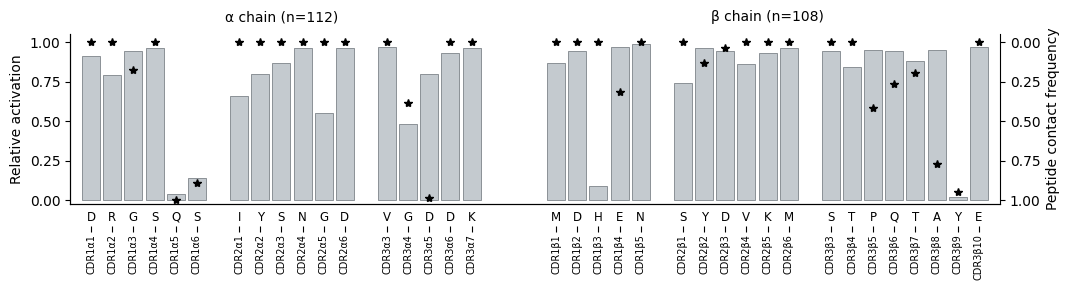

In [65]:
import re, os, json
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

# ========================= inputs =========================
ALA = 'Figures/Figure_3/YF-AlaScan.xlsx'
PEP = 'contact_fingerprint_major_peptide_perpos.csv'   # PEPTIDE contact freq per CDR position

ala = pd.read_excel(ALA, sheet_name='mutants_CDR_AlaScan')
pat = re.compile(r'(CDR\d[AB])_([A-Z])(\d+)([A-Z])')
m = ala['Name'].apply(lambda n: pat.match(str(n)))
ala = ala[m.notna()].copy()
ala[['loop', 'wt', 'posn', 'mut']] = [x.groups() for x in m.dropna()]
ala['posn'] = ala['posn'].astype(int)
is_excl = ala['Comment'].astype(str).str.strip().str.lower().eq('exclude')
ala = ala[(ala['mut'] == 'A') & (~is_excl)].copy()
ala['activation'] = ala['Results'] / 100.0

loop_lab = {'CDR1A': 'CDR1α', 'CDR2A': 'CDR2α', 'CDR3A': 'CDR3α',
            'CDR1B': 'CDR1β', 'CDR2B': 'CDR2β', 'CDR3B': 'CDR3β'}
ala['llab'] = ala['loop'].map(loop_lab)
ala['label'] = ala['llab'] + ala['posn'].astype(str)
cf = pd.read_csv(PEP, index_col=0)['peptide_cf'].to_dict()          # peptide contact frequency
nmod = json.load(open('contact_fingerprint_major_peptide_n.json'))  # model counts per chain

# ========================= x layout (tested positions only) =========================
loop_order = ['CDR1α', 'CDR2α', 'CDR3α', 'CDR1β', 'CDR2β', 'CDR3β']
GAP, CHAIN_GAP = 1.0, 3.0

rows = []
cur = 0.0
for loop in loop_order:
    sub = ala[ala['llab'] == loop].sort_values('posn')
    if sub.empty:
        continue
    if loop == 'CDR1β':
        cur += CHAIN_GAP - GAP
    for _, r in sub.iterrows():
        rows.append((cur, r['label'], r['wt'], r['activation'], cf.get(r['label'], np.nan)))
        cur += 1.0
    cur += GAP
D = pd.DataFrame(rows, columns=['x', 'label', 'wt', 'act', 'cf'])

# ========================= plot =========================
fig, ax = plt.subplots(figsize=(12, 3.2))
trans = ax.get_xaxis_transform()

ax.bar(D['x'], D['act'], width=0.85, color='#C4CACF',
       edgecolor='#4B535A', linewidth=0.4, zorder=2)

# marker * at (1 - peptide contact frequency): on the same scale as the activation bars
for _, r in D.iterrows():
    if pd.notna(r['cf']):
        ax.plot(r['x'], 1 - r['cf'], marker='*', color='black', markersize=6,
                linestyle='none', zorder=4)

# --- labels: aa letters (top, no ticks) | manual ticks + CDR labels (bottom) ---
ax.set_xticks([])
AA_Y    = -0.04                      # amino-acid letter height
TICK_HI, TICK_LO = -0.13, -0.165     # little tick mark (just above CDR labels)
CDR_Y   = -0.18                      # CDR label height
for _, r in D.iterrows():
    ax.text(r['x'], AA_Y, r['wt'], transform=trans,
            ha='center', va='top', fontsize=8.5)                       # aa letter
    ax.vlines(r['x'], TICK_LO, TICK_HI, transform=trans,
              color='black', lw=0.8, clip_on=False)                    # tick -> CDR label
    ax.text(r['x'], CDR_Y, r['label'], transform=trans,
            ha='center', va='top', fontsize=7, rotation=90)            # CDR label

ax.set_ylim(-0.02, 1.05)
ax.set_ylabel('Relative activation')
ax.set_yticks(np.arange(0, 1.01, 0.25))
ax.tick_params(axis='y', labelsize=10)
ax.set_xlim(-1, cur - GAP)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# right y-axis: peptide contact frequency (inverted, since the * markers sit at 1 - cf)
ax2 = ax.twinx()
ax2.set_ylim(1.02, -0.05)                 # value here = 1 - (left value): a * at 1-cf reads cf
ax2.set_yticks(np.arange(0, 1.01, 0.25))
ax2.set_ylabel('Peptide contact frequency')
ax2.tick_params(axis='y', labelsize=10)
ax2.spines['top'].set_visible(False)

# chain titles (centred over each chain's group)
xa = D.loc[D['label'].str.contains('α'), 'x']
xb = D.loc[D['label'].str.contains('β'), 'x']
ax.text((xa.min() + xa.max()) / 2, 1.06, f"α chain (n={nmod['alpha']})", transform=trans,
        ha='center', va='bottom', fontsize=10)
ax.text((xb.min() + xb.max()) / 2, 1.06, f"β chain (n={nmod['beta']})", transform=trans,
        ha='center', va='bottom', fontsize=10)

fig.subplots_adjust(bottom=0.35)
os.makedirs('Figures/Figure_3', exist_ok=True)
fig.savefig('Figures/Figure_3/alascan_peptide.svg', bbox_inches='tight')

## CDR3 SASA

In [54]:
import glob, os, numpy as np, pandas as pd
from Bio.PDB import PDBParser
from Bio.PDB.SASA import ShrakeRupley
from Bio.SeqUtils import seq1

# ===== SASA of CDR3a position 4 (L=10) and CDR3b position 5 (L=13), BOTH binding modes =====
DIRS = {'LAU5013':     'data_julien/LAU5013/YF_LAU5013_sc_WT/model_pdb_align_exp',
        'Public_Data': 'data_julien/Public_Data/YF_public_pairedData_20251010/model_pdb_align_exp'}

anno = []
for b, pat in [('LAU5013', 'data_julien/LAU5013/YF_LAU5013_sc_WT/*.csv'),
               ('Public_Data', 'data_julien/Public_Data/YF_public_pairedData_20251010/*.csv')]:
    a = pd.read_csv(glob.glob(pat)[0]); a['batch'] = b; anno.append(a)
anno = pd.concat(anno).set_index(['batch', 'id'])

dfc = pd.read_csv('df_pca_clusters.csv').copy()            # both modes (cluster 0 + 1)
dfc['la'] = dfc['cdr3_TRA'].str.len(); dfc['lb'] = dfc['cdr3_TRB'].str.len()
dfc['mode'] = np.where(dfc.cluster == 0, 'dominant', 'secondary')

# theoretical max ASA (Tien et al. 2013) for relative SASA
MAXASA = {'A':129,'R':274,'N':195,'D':193,'C':167,'E':223,'Q':225,'G':104,'H':224,'I':197,
          'L':201,'K':236,'M':224,'F':240,'P':159,'S':155,'T':172,'W':285,'Y':263,'V':174}

resl = lambda ch: [r for r in ch if r.id[0] == ' ']
p = PDBParser(QUIET=True); sr = ShrakeRupley()   # Shrake-Rupley SASA

def residue_sasa(rows, chain, col, pos1):
    """SASA (in the complex) of the residue at 1-based position pos1 of the CDR3 in `col`."""
    out = []
    for _, r in rows.iterrows():
        f = os.path.join(DIRS[r['batch']], f"{r['PDB']}.pdb")
        if not os.path.exists(f):
            continue
        st = p.get_structure('x', f)[0]
        sr.compute(st, level="R")                       # per-residue SASA, full complex context
        ch = resl(st[chain]); seq = ''.join(seq1(x.get_resname()) for x in ch)
        i = seq.find(str(r[col]).upper())
        if i < 0:
            continue
        res = ch[i + pos1 - 1]; aa = seq1(res.get_resname())
        out.append({'PDB': r['PDB'], 'batch': r['batch'], 'mode': r['mode'], 'cdr3': r[col],
                    'resn': aa, 'sasa': res.sasa, 'rsasa': res.sasa / MAXASA.get(aa, np.nan)})
    return pd.DataFrame(out)

sasa_a4 = residue_sasa(dfc[dfc.la == 10], 'B', 'cdr3_TRA', 4)   # CDR3a position 4
sasa_b5 = residue_sasa(dfc[dfc.lb == 13], 'C', 'cdr3_TRB', 5)   # CDR3b position 5
sasa_a4['site'] = 'CDR3α4'; sasa_b5['site'] = 'CDR3β5'
df_sasa = pd.concat([sasa_a4, sasa_b5], ignore_index=True)
df_sasa.to_csv('cdr3_sasa_bothmodes.csv', index=False)

for name, d in [('CDR3α4 (L=10)', sasa_a4), ('CDR3β5 (L=13)', sasa_b5)]:
    print(f"{name}: n={len(d)}  "
          f"SASA mean={d.sasa.mean():.1f}±{d.sasa.std():.1f} Å²  "
          f"rSASA mean={d.rsasa.mean():.2f} (median {d.rsasa.median():.2f})")
    for m, dm in d.groupby('mode'):
        print(f"    {m}: n={len(dm)}  SASA {dm.sasa.mean():.1f}±{dm.sasa.std():.1f}  rSASA {dm.rsasa.mean():.2f}")

CDR3α4 (L=10): n=339  SASA mean=2.0±3.8 Å²  rSASA mean=0.01 (median 0.00)
    dominant: n=338  SASA 2.0±3.8  rSASA 0.01
    secondary: n=1  SASA 1.2±nan  rSASA 0.01
CDR3β5 (L=13): n=175  SASA mean=34.4±22.5 Å²  rSASA mean=0.18 (median 0.17)
    dominant: n=151  SASA 33.7±22.6  rSASA 0.17
    secondary: n=24  SASA 39.0±21.4  rSASA 0.20


In [55]:
for name, d in [('CDR3α4', sasa_a4), ('CDR3β5', sasa_b5)]:
    n = len(d)
    print(f"{name}: rSASA mean={d.rsasa.mean():.3f} ± {d.rsasa.std():.3f} SD "
          f"(SEM {d.rsasa.std()/np.sqrt(n):.3f}, n={n})")

CDR3α4: rSASA mean=0.012 ± 0.024 SD (SEM 0.001, n=339)
CDR3β5: rSASA mean=0.177 ± 0.075 SD (SEM 0.006, n=175)


/var/folders/mg/jhh2rvf11vd1jd013_6qqg200000gn/T/ipykernel_59830/3332181297.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xlab, fontsize=10)


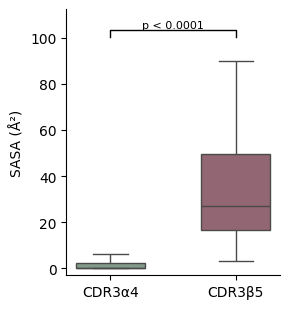

In [56]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from scipy.stats import mannwhitneyu

df_sasa = pd.read_csv('cdr3_sasa_major.csv')

order  = ['CDR3α4', 'CDR3β5']
pal    = {'CDR3α4': '#7E9E85', 'CDR3β5': '#9A5E72'}   # green (alpha) / mauve (beta)
n      = df_sasa.groupby('site').size()
#xlab   = [f"{s}\n(n={n[s]})" for s in order]
xlab   = [s for s in order]

def p_text(p):
    return 'p < 0.0001' if p < 1e-4 else f'p = {p:.3g}'

fig, ax = plt.subplots(figsize=(3, 3.2))
sns.boxplot(df_sasa, x='site', y='sasa', order=order, hue='site', palette=pal,
            legend=False, width=0.55, fliersize=0, linewidth=1, ax=ax)
ax.set_xlabel(''); ax.set_ylabel('SASA (Å²)')
ax.set_xticklabels(xlab, fontsize=10)
ax.tick_params(axis='y', labelsize=10)

# significance: Mann-Whitney U (independent groups, different n)
a = df_sasa.loc[df_sasa.site == order[0], 'sasa']
b = df_sasa.loc[df_sasa.site == order[1], 'sasa']
U, p = mannwhitneyu(a, b, alternative='two-sided')
ymax = df_sasa['sasa'].max()

y = ymax-20
h = y * 0.03

ax.plot([0, 0, 1, 1], [y, y + h, y + h, y], lw=1, color='black')
ax.text(0.5, y + h, p_text(p), ha='center', va='bottom', fontsize=8)
ax.set_ylim(-3, y + h * 4)

sns.despine(fig)
fig.tight_layout()
fig.savefig('Figures/Figure_3/cdr3_sasa_box.svg', bbox_inches='tight')

## CDR3 mutation scan

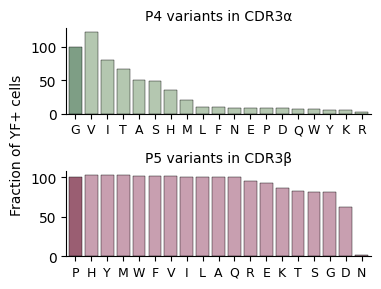

In [28]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt

SCAN = 'Figures/Figure_3/YF-CDR3Scan.xlsx'
d = pd.read_excel(SCAN)

panels = [('CDR3aP4', 'cdr3_TRA', 4, 'G', 'P4 variants in CDR3α', '#7E9E85', '#B4C7B0'),
          ('CDR3bP5', 'cdr3_TRB', 5, 'P', 'P5 variants in CDR3β', '#9A5E72', '#C89FB0')]

fig, axes = plt.subplots(2, 1, figsize=(4, 3))
for ax, (note, col, pos, wt, title, wt_col, oth_col) in zip(axes, panels):
    sub = d[d['Note'] == note].copy()
    sub['aa'] = sub[col].str[pos - 1]
    g = sub.groupby('aa')['Norm_Percentage'].mean()          # average replicates per residue

    others = g.drop(wt).sort_values(ascending=False)         # WT first, then descending
    order  = [wt] + list(others.index)
    vals   = [g[wt]] + list(others.values)
    cols   = [wt_col] + [oth_col] * len(others)

    x = np.arange(len(order))
    ax.bar(x, vals, width=0.8, color=cols, edgecolor='black', linewidth=0.3)
    ax.set_xticks(x); ax.set_xticklabels(order, fontsize=9)
    ax.set_title(title, fontsize=10)
    ax.tick_params(axis='y', labelsize=10)
    ax.margins(x=0.01)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.supylabel('Fraction of YF+ cells', fontsize=10, x=0.06)   # shared y-label
fig.tight_layout()
fig.savefig('Figures/Figure_3/cdr3_scan.svg', bbox_inches='tight')

## CDR2.5 contact frequency / mutation scan

In [32]:
import os, numpy as np, pandas as pd
from Bio.PDB import PDBParser
from Bio.SeqUtils import seq1
from scipy.spatial.distance import cdist
from anarci import anarci

# ===== HV4 / CDR4 ("CDR2.5") loop contact frequency with peptide vs MHC =====
#   loop = IMGT positions 81-86 of the TCRalpha V domain (located per model via ANARCI)
#   genes compared separately: TRAV12-2, TRAV12-1, TRAV27
CUTOFF = 3.5
HV4    = range(81, 87)                      # IMGT 81-86
GENES  = ['TRAV12-2', 'TRAV12-1', 'TRAV27']
DIRS = {'LAU5013':     'data_julien/LAU5013/YF_LAU5013_sc_WT/model_pdb_align_exp',
        'Public_Data': 'data_julien/Public_Data/YF_public_pairedData_20251010/model_pdb_align_exp'}

df = pd.read_pickle('coord_matrix.pkl')
df = df[df['AF3_iptm_pair_mean'] > 0.8].copy()
df['pid'] = df['PDB'].apply(lambda x: os.path.basename(str(x)).split('.')[0])

resl   = lambda ch: [r for r in ch if r.id[0] == ' ']
heavy1 = lambda r: np.array([a.get_coord() for a in r if a.element != 'H'])
heavyL = lambda res: (np.vstack([heavy1(r) for r in res]) if res else np.empty((0, 3)))
p = PDBParser(QUIET=True)

def hv4_contacts(row):
    """per HV4 position: (residue, peptide_contact, mhc_contact) for one model."""
    f = os.path.join(DIRS[row['batch']], f"{row['pid']}.pdb")
    if not os.path.exists(f):
        return None
    st = p.get_structure('x', f)[0]
    chB = resl(st['B']); seq = ''.join(seq1(r.get_resname()) for r in chB)
    num = anarci([('x', seq)], scheme='imgt', output=False)[0]
    if num[0] is None:
        return None
    numlist, start, _ = num[0][0]
    pep = heavyL(resl(st['E'])); mhc = heavyL(resl(st['A']))
    idx, out = start, {}
    for (pos, ins), aa in numlist:
        if aa == '-':
            continue
        if pos in HV4:
            ra = heavy1(chB[idx])
            dp = cdist(ra, pep).min() if (ra.size and pep.size) else np.inf
            dm = cdist(ra, mhc).min() if (ra.size and mhc.size) else np.inf
            out[pos] = (aa, dp <= CUTOFF, dm <= CUTOFF)
        idx += 1
    return out

records, counts = [], {}
for gene in GENES:
    sub = df[df['TRAV'] == gene]
    pep_c, mhc_c, epi_c, res_aa, n = {}, {}, {}, {}, 0
    for _, r in sub.iterrows():
        o = hv4_contacts(r)
        if o is None:
            continue
        n += 1
        for pos, (aa, cp, cm) in o.items():
            res_aa.setdefault(pos, {}).setdefault(aa, 0)
            res_aa[pos][aa] += 1
            pep_c[pos] = pep_c.get(pos, 0) + int(cp)
            mhc_c[pos] = mhc_c.get(pos, 0) + int(cm)
            epi_c[pos] = epi_c.get(pos, 0) + int(cp or cm)
    counts[gene] = n
    for pos in HV4:
        if pos not in res_aa:
            continue
        aa = max(res_aa[pos], key=res_aa[pos].get)         # germline residue (most common)
        records.append({'gene': gene, 'n': n, 'imgt': pos, 'resn': aa,
                        'peptide_cf': pep_c.get(pos, 0) / n,
                        'mhc_cf':     mhc_c.get(pos, 0) / n,
                        'epitope_cf': epi_c.get(pos, 0) / n})

hv4_df = pd.DataFrame(records)
hv4_df.to_csv('hv4_contacts_by_gene.csv', index=False)
print('models per gene:', counts)
print(hv4_df.round(2).to_string(index=False))

models per gene: {'TRAV12-2': 403, 'TRAV12-1': 50, 'TRAV27': 22}
    gene   n  imgt resn  peptide_cf  mhc_cf  epitope_cf
TRAV12-2 403    81    N         0.0    0.00        0.00
TRAV12-2 403    82    K         0.0    0.76        0.76
TRAV12-2 403    83    A         0.0    0.00        0.00
TRAV12-2 403    84    S         0.0    0.00        0.00
TRAV12-2 403    85    Q         0.0    0.00        0.00
TRAV12-2 403    86    Y         0.0    0.00        0.00
TRAV12-1  50    81    N         0.0    0.00        0.00
TRAV12-1  50    82    R         0.0    0.80        0.80
TRAV12-1  50    83    A         0.0    0.00        0.00
TRAV12-1  50    84    S         0.0    0.00        0.00
TRAV12-1  50    85    Q         0.0    0.00        0.00
TRAV12-1  50    86    Y         0.0    0.00        0.00
  TRAV27  22    81    G         0.0    0.00        0.00
  TRAV27  22    82    D         0.0    0.00        0.00
  TRAV27  22    83    A         0.0    0.00        0.00
  TRAV27  22    84    R         0.0    

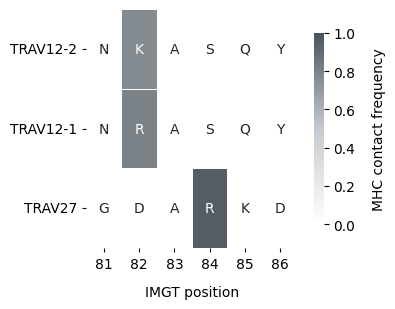

In [45]:
import pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

# ===== Panel E (left): HV4 / CDR2.5α model MHC contact, 3 Vα genes =====
hv4_df = pd.read_csv('hv4_contacts_by_gene.csv')          # from the HV4 analysis cell

genes = ['TRAV12-2', 'TRAV12-1', 'TRAV27']; cols = list(range(81, 87))
M = hv4_df.pivot(index='gene', columns='imgt', values='mhc_cf').reindex(genes)[cols]
R = hv4_df.pivot(index='gene', columns='imgt', values='resn').reindex(genes)[cols]
cm = LinearSegmentedColormap.from_list('grey', ['#FFFFFF', '#C4CACF', '#4B535A'])

fig, ax = plt.subplots(figsize=(4, 3.2))
sns.heatmap(M, annot=R.values, fmt='', cmap=cm, vmin=0, vmax=1,
            linewidths=0.5, linecolor='white', annot_kws={'fontsize': 10},
            cbar_kws={'label': 'MHC contact frequency', 'shrink': 0.8, 'pad': 0.06}, ax=ax)
ax.set_xticklabels(cols, fontsize=10); ax.set_yticklabels(genes, rotation=0, fontsize=10)
ax.set_xlabel('IMGT position', fontsize=10, labelpad=10)       # more space before the label
ax.set_ylabel('')
ax.tick_params(length=3, bottom=True, left=True)               # show tick marks on both axes

cbar = ax.collections[0].colorbar
cbar.ax.yaxis.labelpad = 12          # space between the colorbar and its label

fig.tight_layout()
fig.savefig('Figures/Figure_3/panelE_models.svg', bbox_inches='tight')

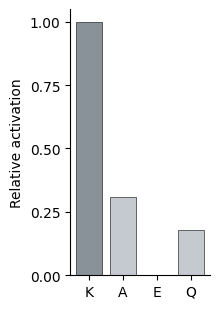

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

# ===== Panel E (right): experimental K82 (CDR2.5α) variant activation =====
# PLACEHOLDER estimates from the dot plot — replace with raw data later.
df_e = pd.DataFrame({'mut': ['K', 'A', 'E', 'Q'], 'activation': [1.00, 0.31, 0.00, 0.18]})

wt_col, mut_col = '#8A9299', '#C4CACF'        # two lighter greys (WT darker / mutants lighter)
colors = [wt_col if m == 'K' else mut_col for m in df_e['mut']]

fig, ax = plt.subplots(figsize=(2.3, 3.2))
ax.bar(np.arange(len(df_e)), df_e['activation'], width=0.75,
       color=colors, edgecolor='black', linewidth=0.4)
ax.set_xticks(np.arange(len(df_e))); ax.set_xticklabels(df_e['mut'], fontsize=10)
ax.set_ylabel('Relative activation', fontsize=10); ax.set_ylim(0, 1.05)
ax.set_yticks(np.arange(0, 1.01, 0.25)); ax.tick_params(axis='y', labelsize=10)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

fig.tight_layout()
fig.savefig('Figures/Figure_3/panelE_exp.svg', bbox_inches='tight')

# Design mutants to test experimentally

In [4]:
import pandas as pd

# ===== Build mutants_design.xlsx (full TRA/TRB reconstructed from IMGT germline + CDR3) =====
GENE = '../MixTCRviz/data_raw/CDR123/HomoSapiens'        # CDR123 reference tables
trav = pd.read_csv(f'{GENE}/TRAV.csv', index_col=0); traj = pd.read_csv(f'{GENE}/TRAJ.csv', index_col=0)
trbv = pd.read_csv(f'{GENE}/TRBV.csv', index_col=0); trbj = pd.read_csv(f'{GENE}/TRBJ.csv', index_col=0)

def build_chain(Vdf, Jdf, V, J, cdr3):
    """full chain = V germline (gaps removed, minus its partial CDR3) + CDR3 + J germline (after its CDR3)."""
    Vfull = Vdf.loc[V, 'full'].replace('-', ''); Vc = Vdf.loc[V, 'CDR3']
    Jfull = Jdf.loc[J, 'full'].replace('-', ''); Jc = Jdf.loc[J, 'CDR3']
    return Vfull[:-len(Vc)] + cdr3 + Jfull[len(Jc):]

# shared beta chain for every design (TRBV9 / CASSAGTGAYEQYF / TRBJ2-7) -> chosen cdr3 is the most common for TRBV9 / TRBJ2-7
TRBV_, TRBJ_, CDR3B = 'TRBV9', 'TRBJ2-7', 'CASSAGTGAYEQYF'
TRB = build_chain(trbv, trbj, TRBV_, TRBJ_, CDR3B)

# alpha designs: (Name, TRAV label, TRAJ, cdr3_TRA, HV4-R69 mutation or None)
specs = [
    ('template_dominant',  'TRAV12-2',        'TRAJ30', 'CAVGDDKIIF',    None),
    ('template_secondary', 'TRAV27',          'TRAJ43', 'CAGVSARLNDMRF', None), # chosen cdr3 is the most common for TRAV27 / TRAJ43
    ('mix_dominant_secondary', 'TRAV12-2',        'TRAJ49', 'CAVPPDTGNQFYF', None), # TRAV12-2 and TRAJ49 are naturally paired but with L=10 cdr3s
    ('mix_secondary_dominant', 'TRAV27',          'TRAJ30', 'CAGGDDKIIF',    None), # here one pairing but with L=13 cdr3
    ('secondary_R69A',     'TRAV27_modified', 'TRAJ43', 'CAGVSARLNDMRF', 'A'),
    ('secondary_R69E',     'TRAV27_modified', 'TRAJ43', 'CAGVSARLNDMRF', 'E'),
    ('secondary_R69Q',     'TRAV27_modified', 'TRAJ43', 'CAGVSARLNDMRF', 'Q'),
]

rows = []
for name, trav_label, J, cdr3a, mut in specs:
    V = trav_label.replace('_modified', '')                       # gene used to build the sequence
    TRA = build_chain(trav, traj, V, J, cdr3a)
    if mut is not None:                                           # R69 = HV4 Arg in the GDARKD motif
        assert TRA.count('GDARKD') == 1, f'GDARKD not unique in {name}'
        TRA = TRA.replace('GDARKD', f'GDA{mut}KD')
    rows.append({'Name': name, 'TRA': TRA, 'TRB': TRB,
                 'TRAV': trav_label, 'TRAJ': J, 'cdr3_TRA': cdr3a,
                 'TRBV': TRBV_, 'TRBJ': TRBJ_, 'cdr3_TRB': CDR3B})

design = pd.DataFrame(rows, columns=['Name', 'TRA', 'TRB', 'TRAV', 'TRAJ',
                                     'cdr3_TRA', 'TRBV', 'TRBJ', 'cdr3_TRB'])
design.to_excel('mutants_design.xlsx', sheet_name='mutants_design', index=False)
design

,Name,TRA,TRB,TRAV,TRAJ,cdr3_TRA,TRBV,TRBJ,cdr3_TRB
0,template_dominant,QKEVEQNSGPLSVPEGAIASLNCTYSDRGSQSFFWYRQYSGKSPEL...,DSGVTQTPKHLITATGQRVTLRCSPRSGDLSVYWYQQSLDQGLQFL...,TRAV12-2,TRAJ30,CAVGDDKIIF,TRBV9,TRBJ2-7,CASSAGTGAYEQYF
1,template_secondary,TQLLEQSPQFLSIQEGENLTVYCNSSSVFSSLQWYRQEPGEGPVLL...,DSGVTQTPKHLITATGQRVTLRCSPRSGDLSVYWYQQSLDQGLQFL...,TRAV27,TRAJ43,CAGVSARLNDMRF,TRBV9,TRBJ2-7,CASSAGTGAYEQYF
2,mix_dominant_secondary,QKEVEQNSGPLSVPEGAIASLNCTYSDRGSQSFFWYRQYSGKSPEL...,DSGVTQTPKHLITATGQRVTLRCSPRSGDLSVYWYQQSLDQGLQFL...,TRAV12-2,TRAJ49,CAVPPDTGNQFYF,TRBV9,TRBJ2-7,CASSAGTGAYEQYF
3,mix_secondary_dominant,TQLLEQSPQFLSIQEGENLTVYCNSSSVFSSLQWYRQEPGEGPVLL...,DSGVTQTPKHLITATGQRVTLRCSPRSGDLSVYWYQQSLDQGLQFL...,TRAV27,TRAJ30,CAGGDDKIIF,TRBV9,TRBJ2-7,CASSAGTGAYEQYF
4,secondary_R69A,TQLLEQSPQFLSIQEGENLTVYCNSSSVFSSLQWYRQEPGEGPVLL...,DSGVTQTPKHLITATGQRVTLRCSPRSGDLSVYWYQQSLDQGLQFL...,TRAV27_modified,TRAJ43,CAGVSARLNDMRF,TRBV9,TRBJ2-7,CASSAGTGAYEQYF
5,secondary_R69E,TQLLEQSPQFLSIQEGENLTVYCNSSSVFSSLQWYRQEPGEGPVLL...,DSGVTQTPKHLITATGQRVTLRCSPRSGDLSVYWYQQSLDQGLQFL...,TRAV27_modified,TRAJ43,CAGVSARLNDMRF,TRBV9,TRBJ2-7,CASSAGTGAYEQYF
6,secondary_R69Q,TQLLEQSPQFLSIQEGENLTVYCNSSSVFSSLQWYRQEPGEGPVLL...,DSGVTQTPKHLITATGQRVTLRCSPRSGDLSVYWYQQSLDQGLQFL...,TRAV27_modified,TRAJ43,CAGVSARLNDMRF,TRBV9,TRBJ2-7,CASSAGTGAYEQYF
